In [1]:
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import plotnine 
from plotnine import (
    ggplot, geom_point, aes, scale_fill_distiller,
    geom_tile, theme, element_text, element_blank)
from plotnine.facets import facet_grid
import plotnine
from typing import List, Union, Optional, Tuple

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/tscc/projects/ps-epigen/bpToolbox/Scenic/scripts/"))
from heatmap_utils import *

done loading libraries


## Inputs

In [4]:
proj_path = "scplus_pipeline_otsu"
celltype_col = "leiden"
condition_col = "condition"
outdir = "Reports_otsu"

In [5]:
os.makedirs(f"{outdir}", exist_ok = True)
scplus_mdata = mudata.read(f"{proj_path}/Snakemake/scplusmdata.h5mu")

/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/tscc/nfs/home/rlancione/miniconda3

## Reports 

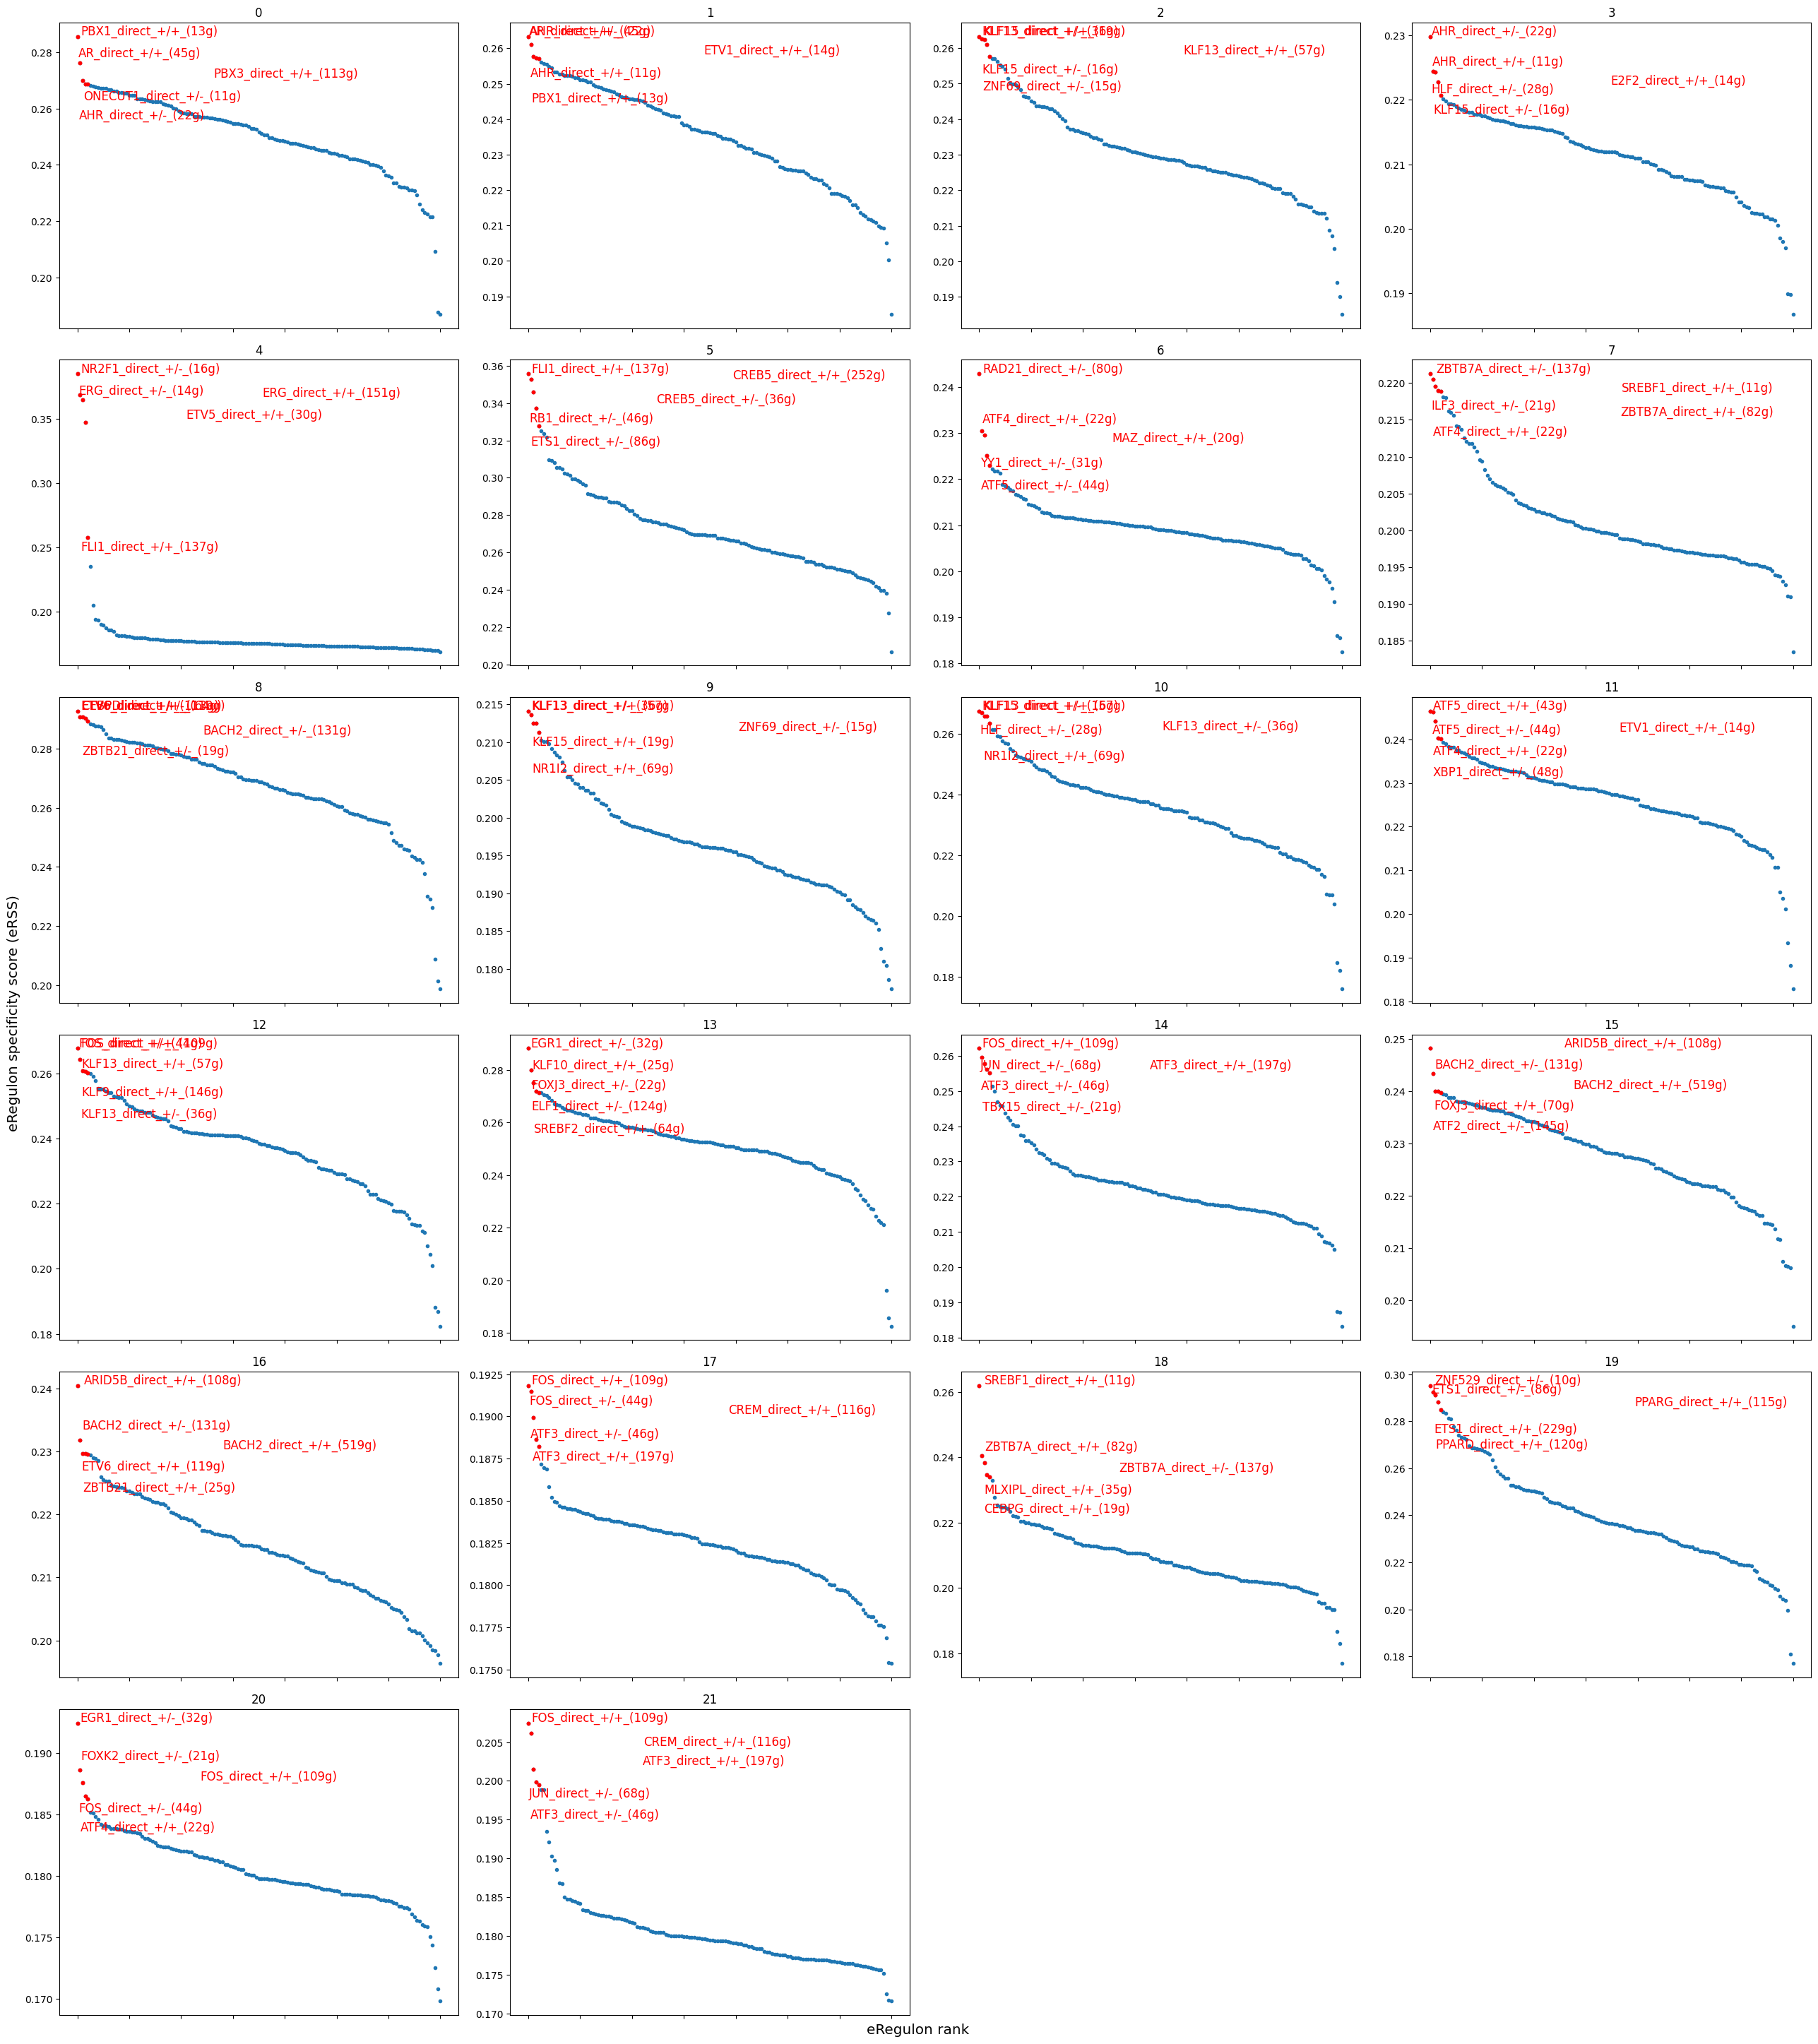

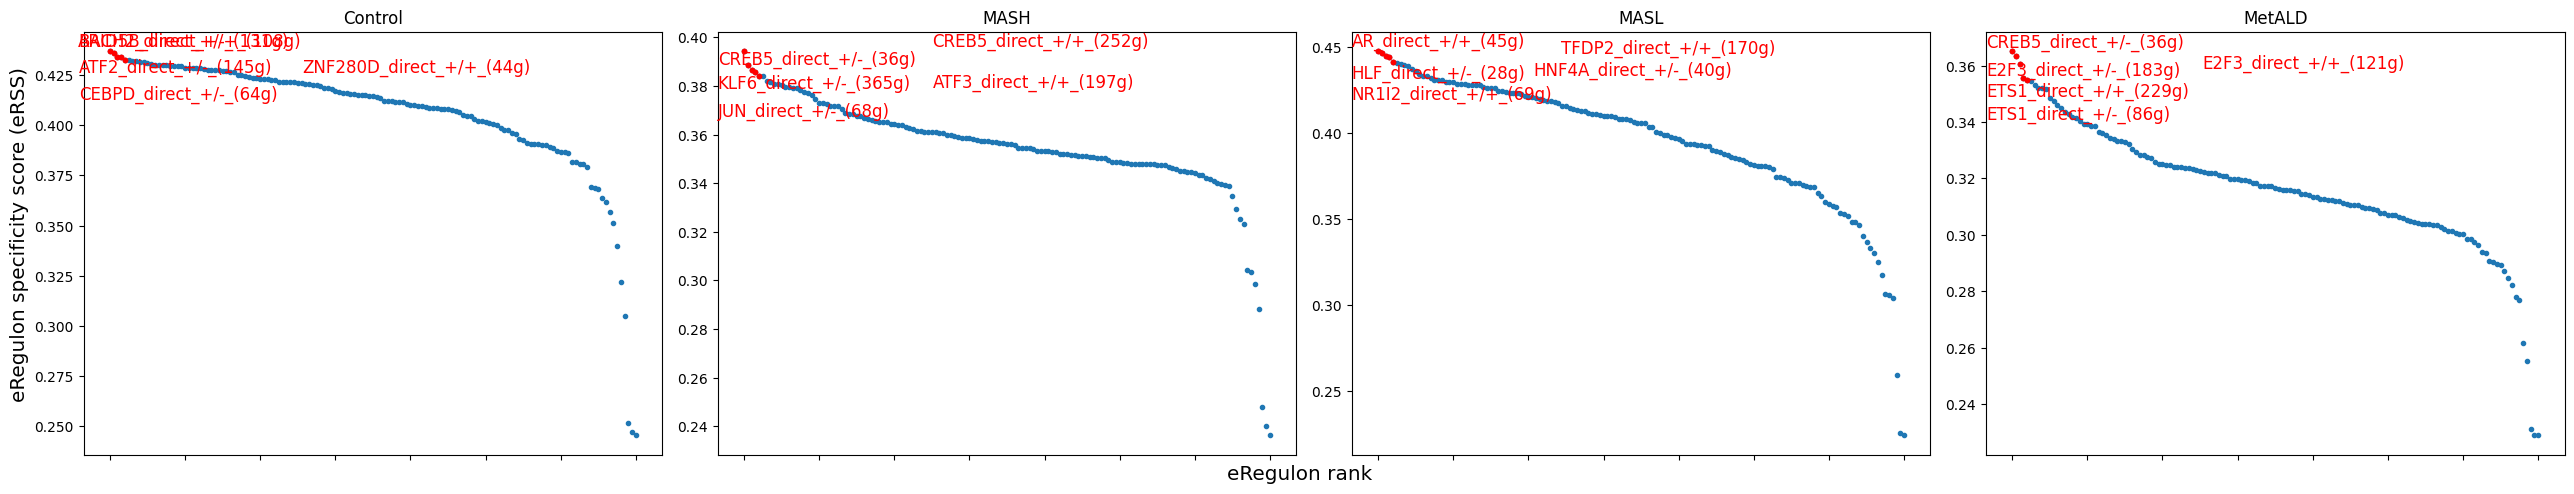

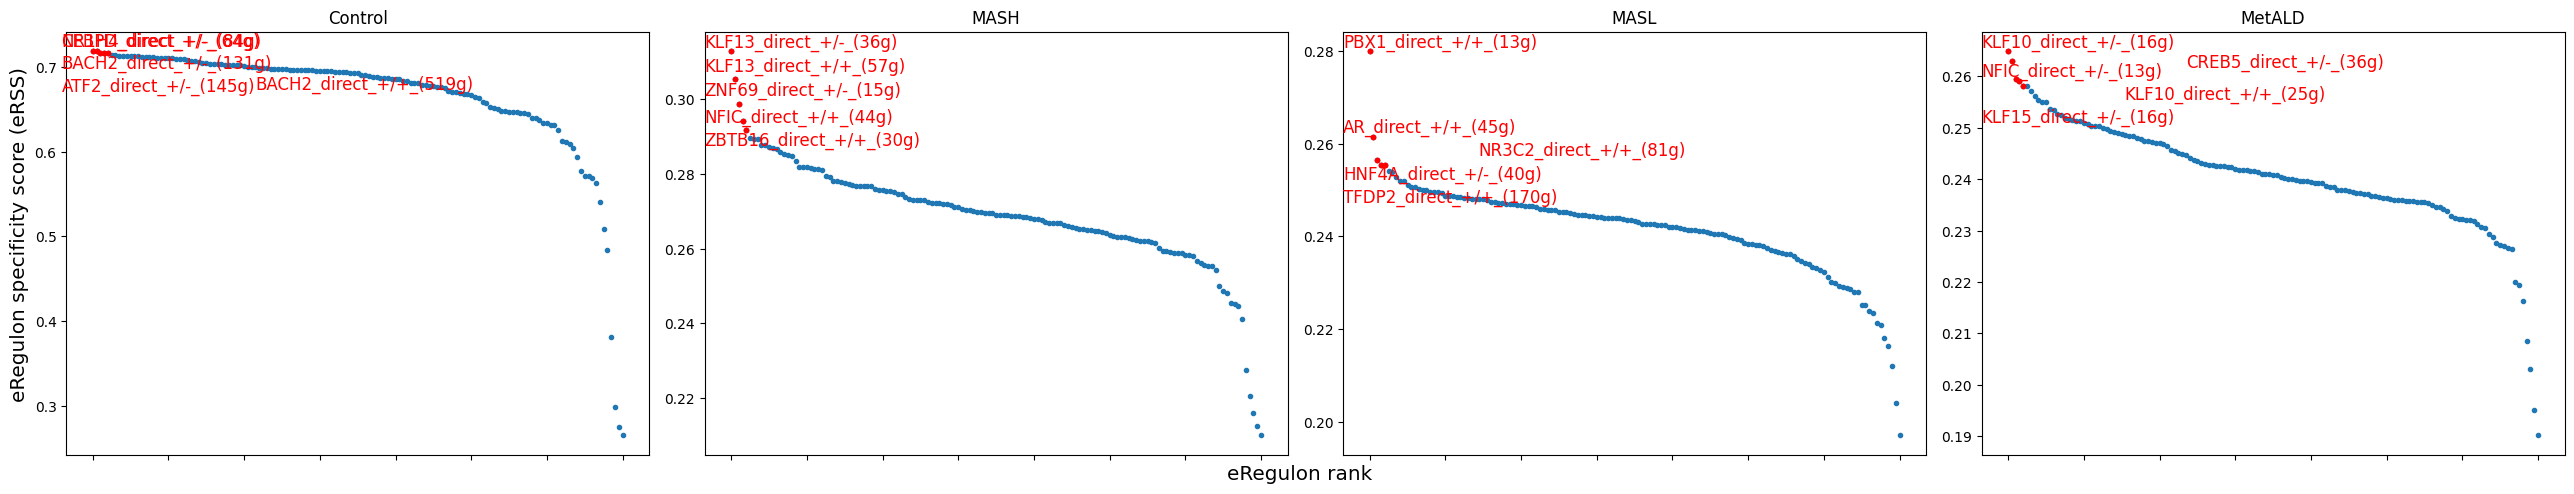

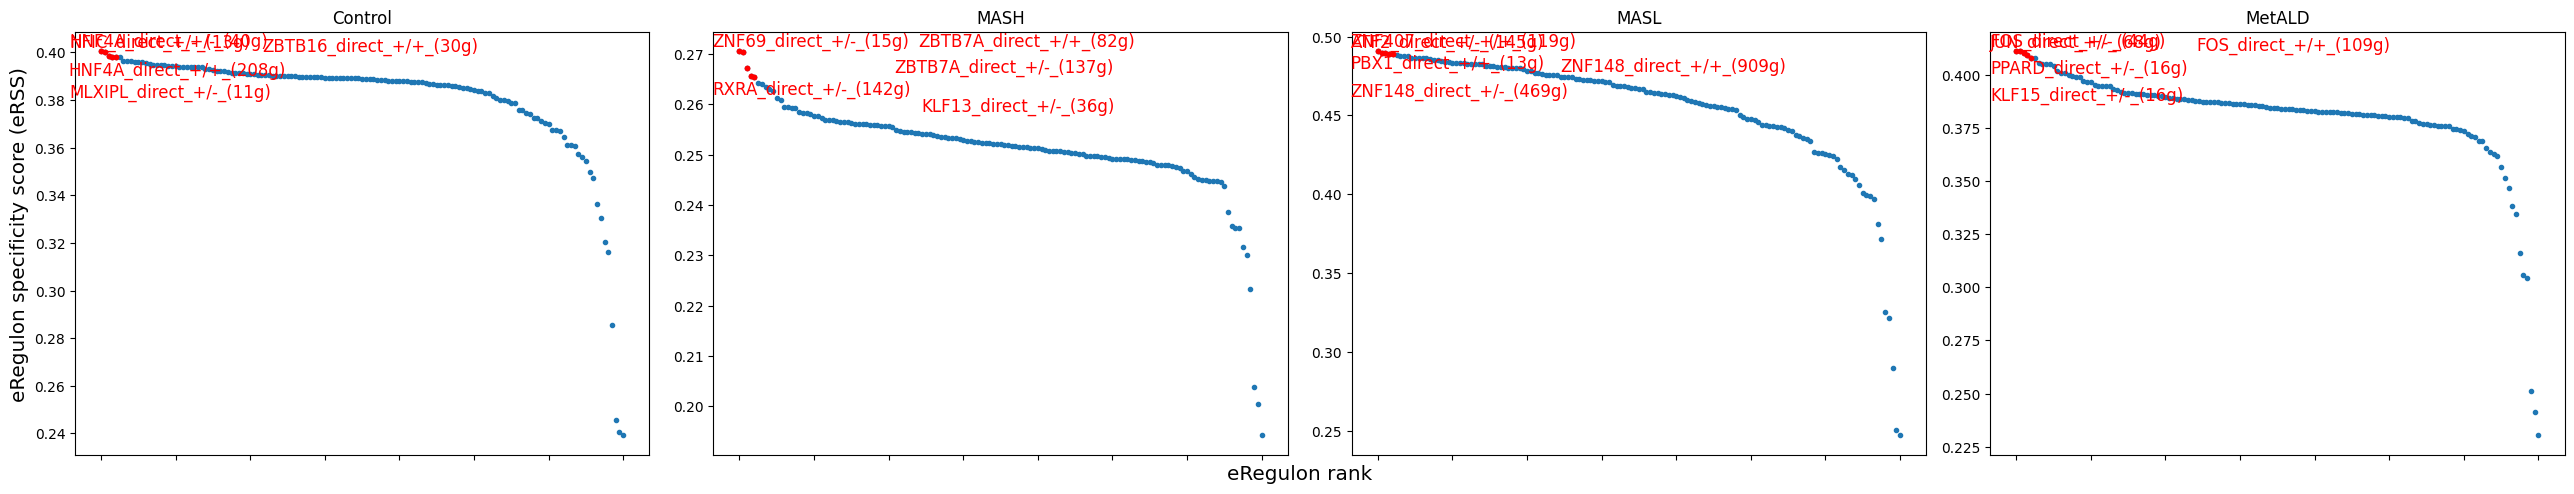

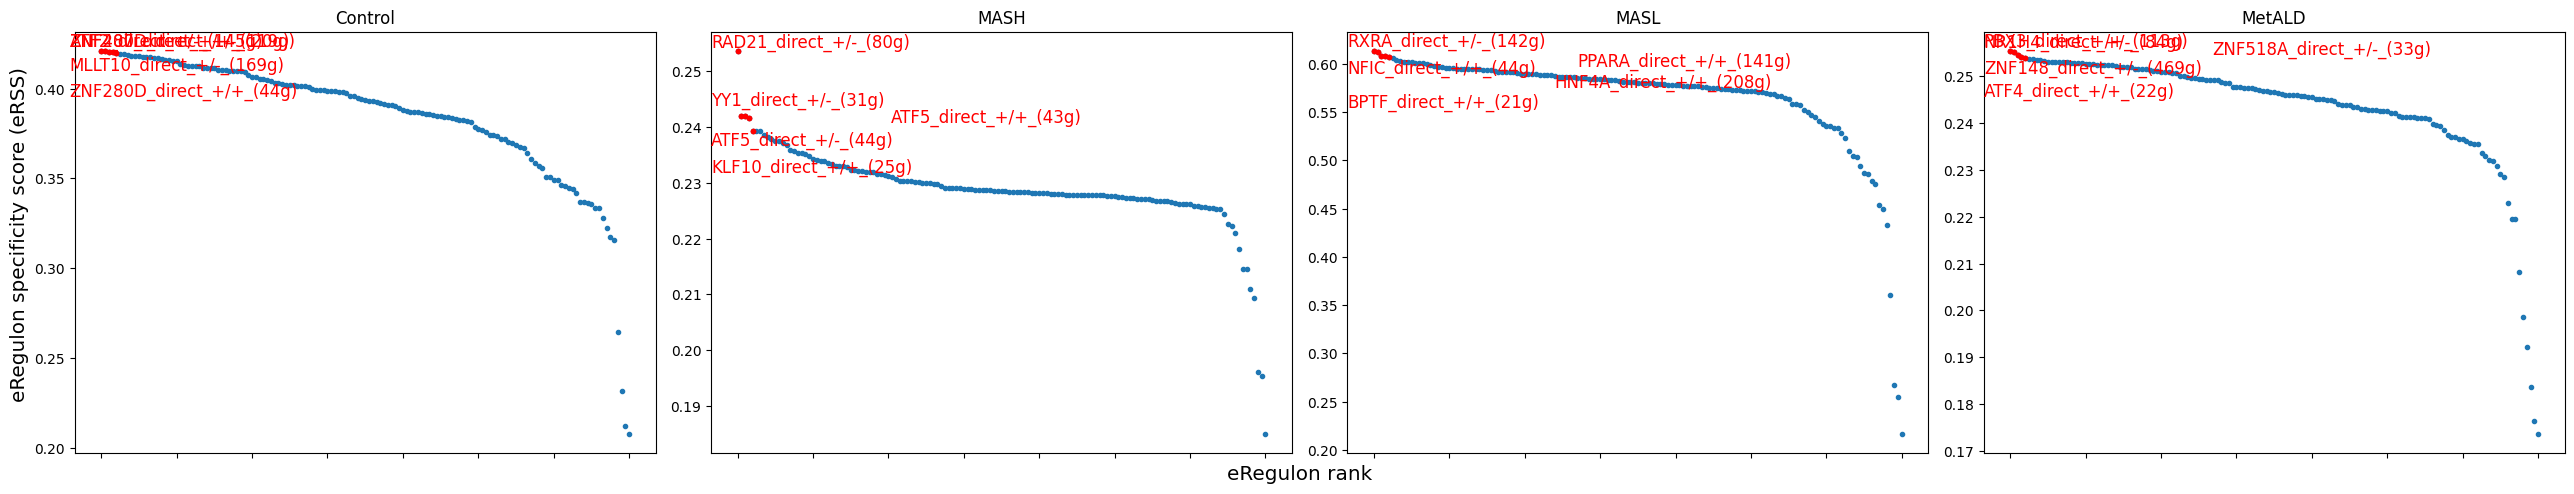

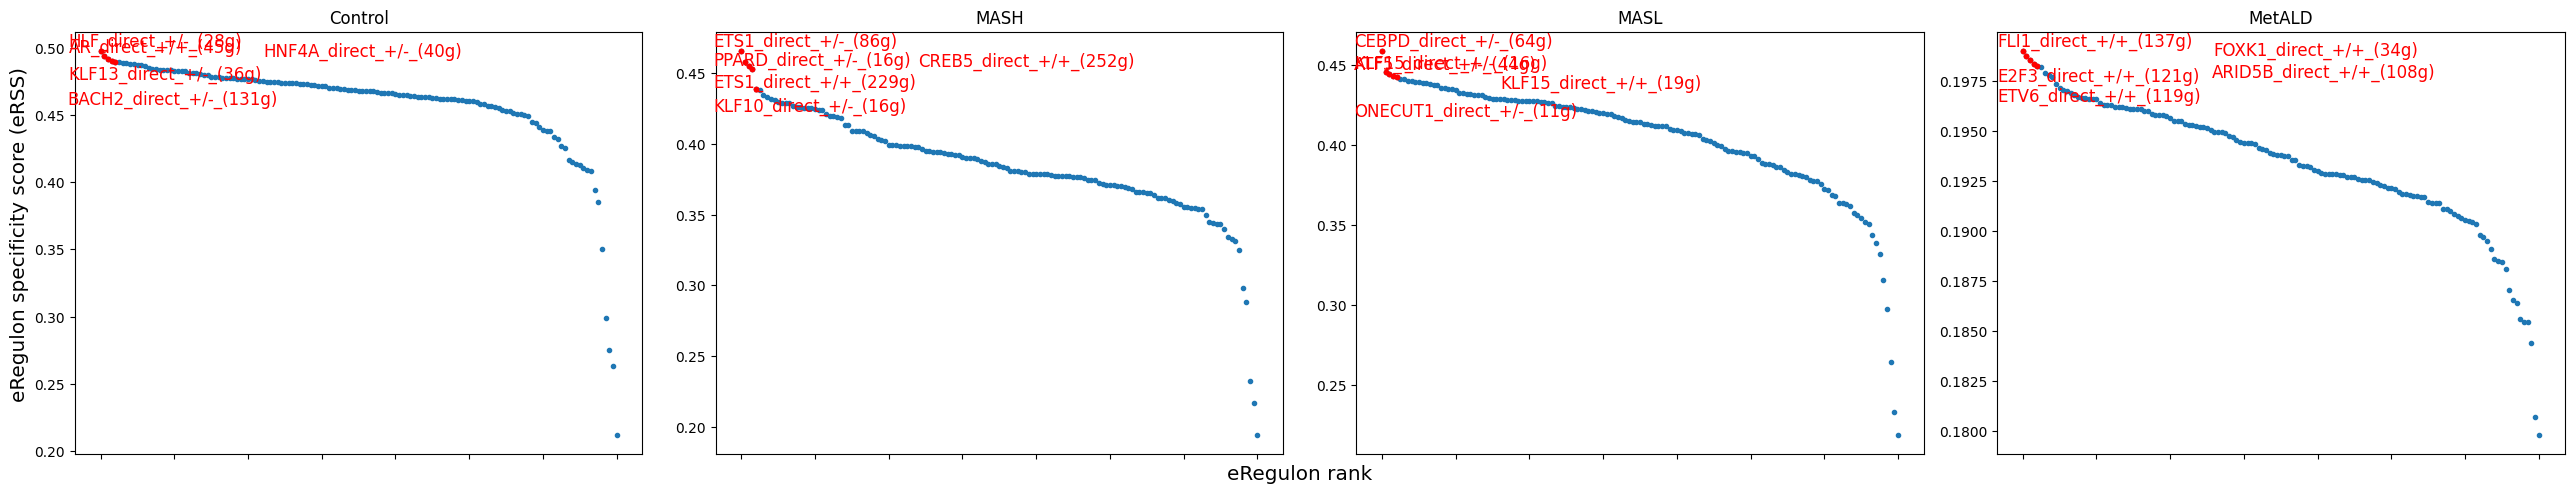

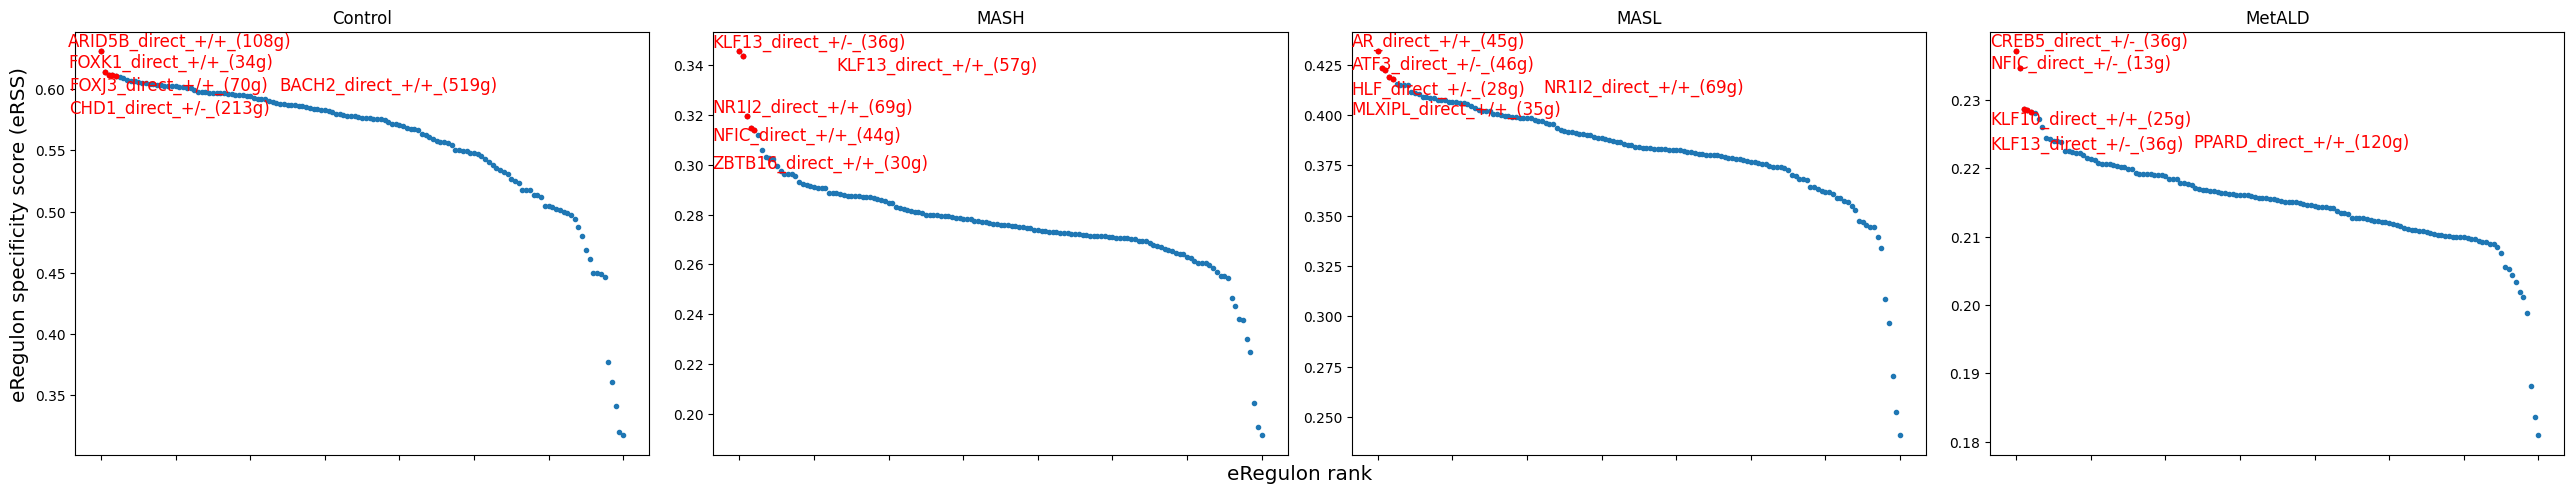

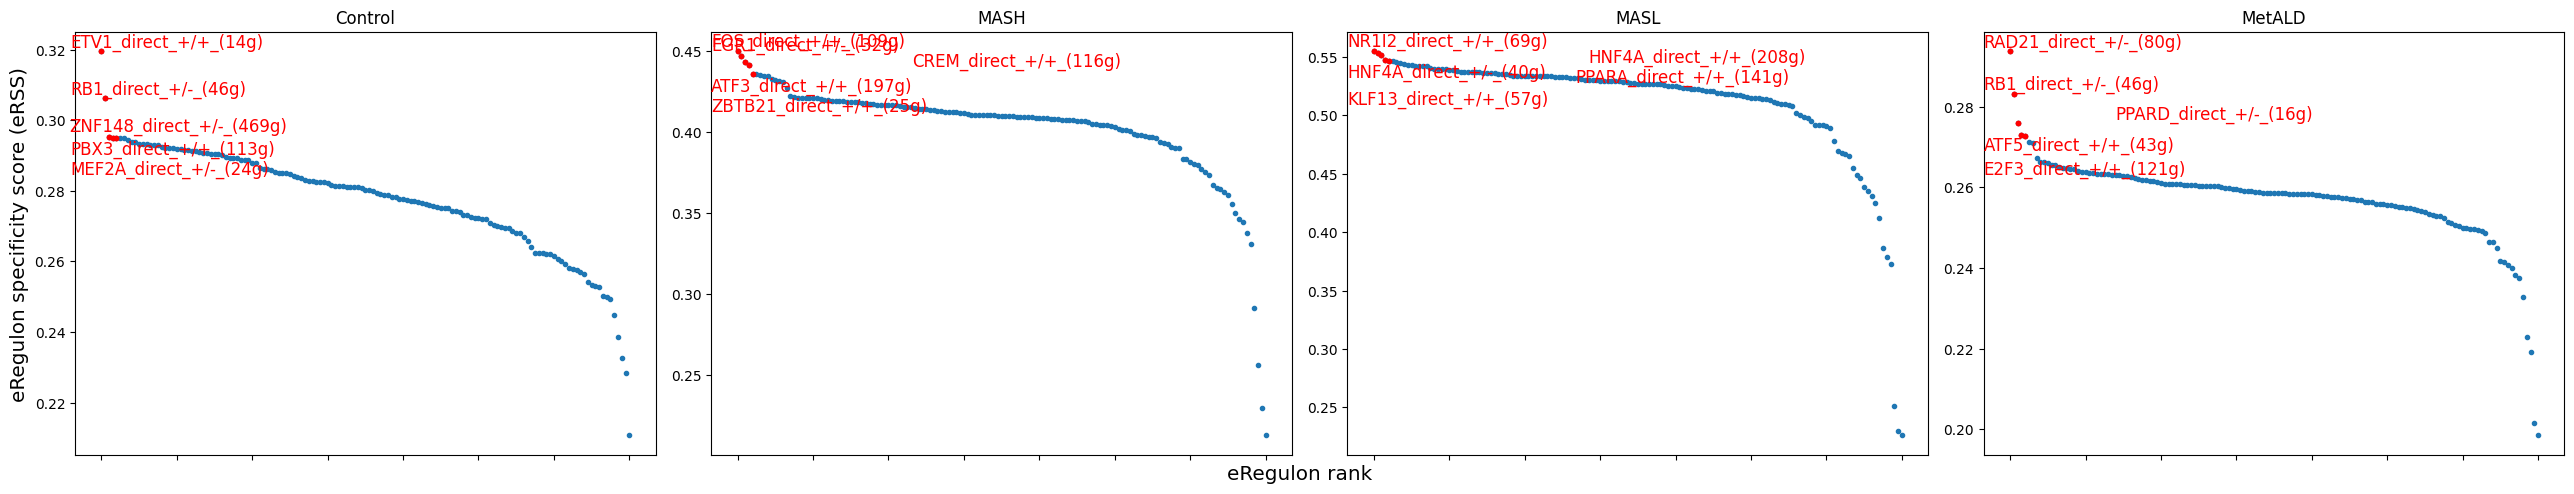

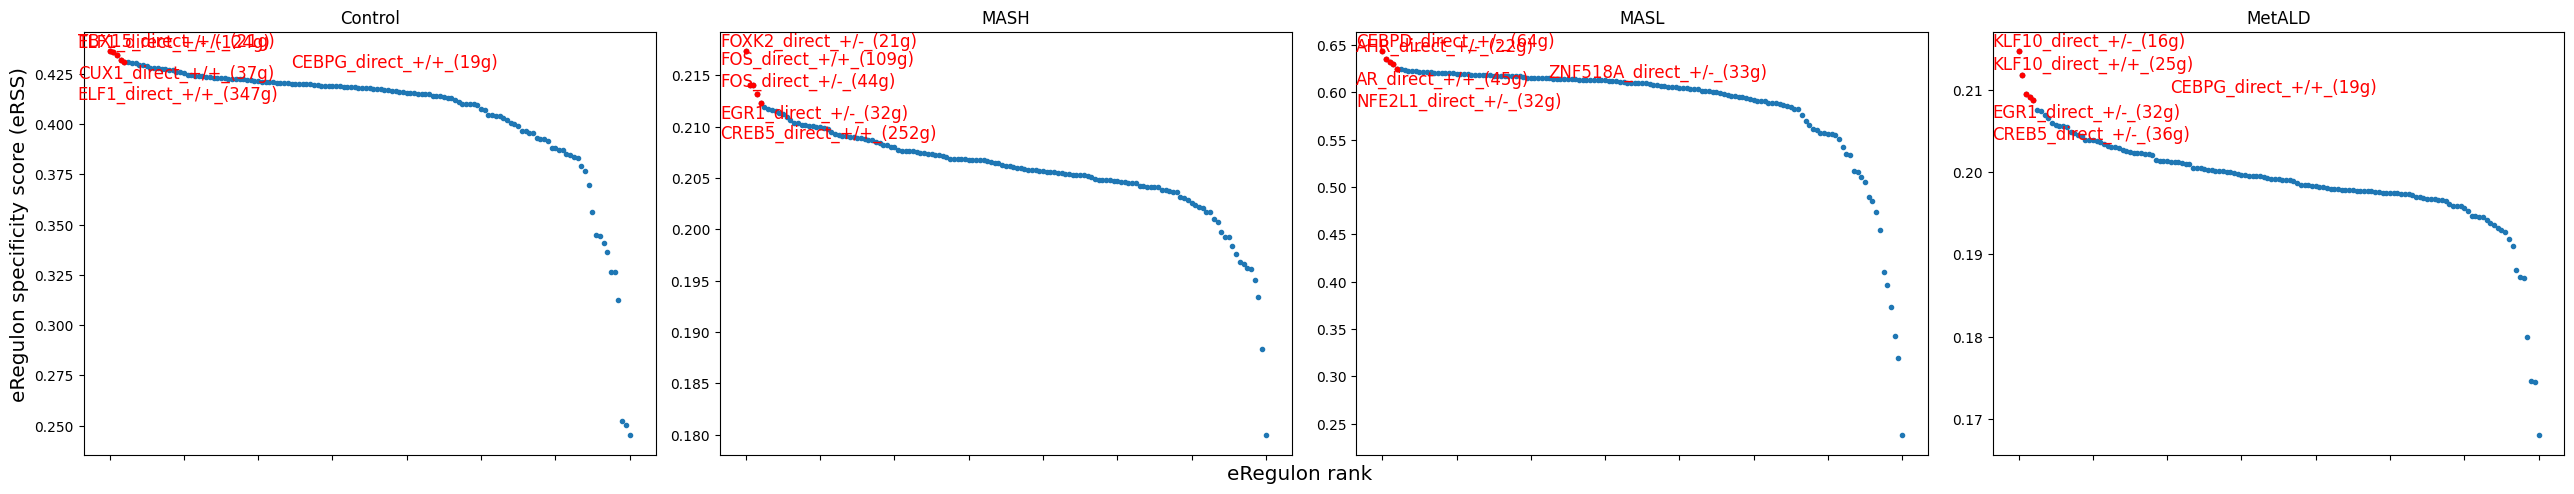

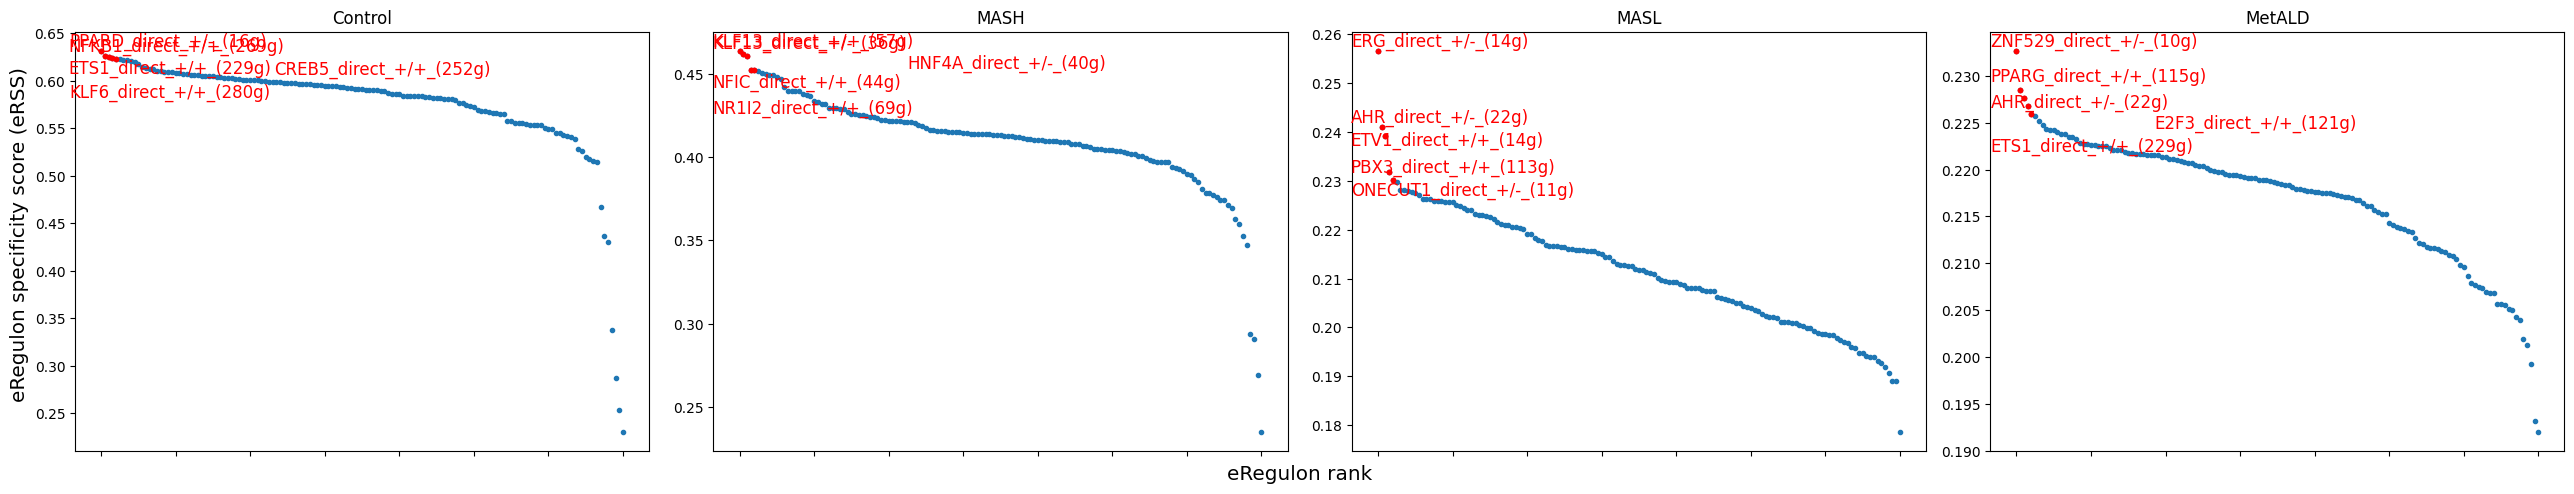

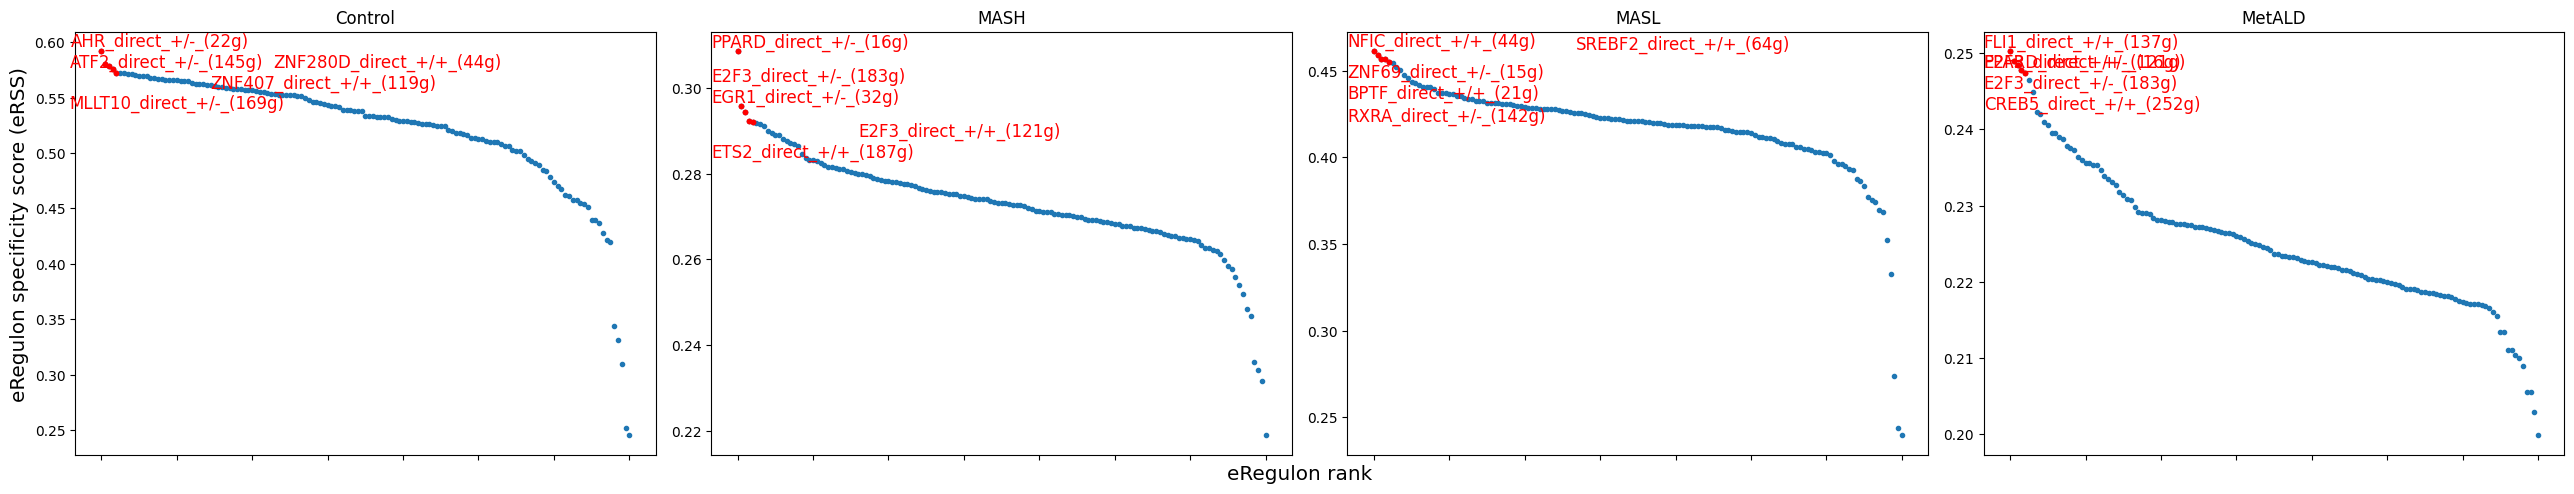

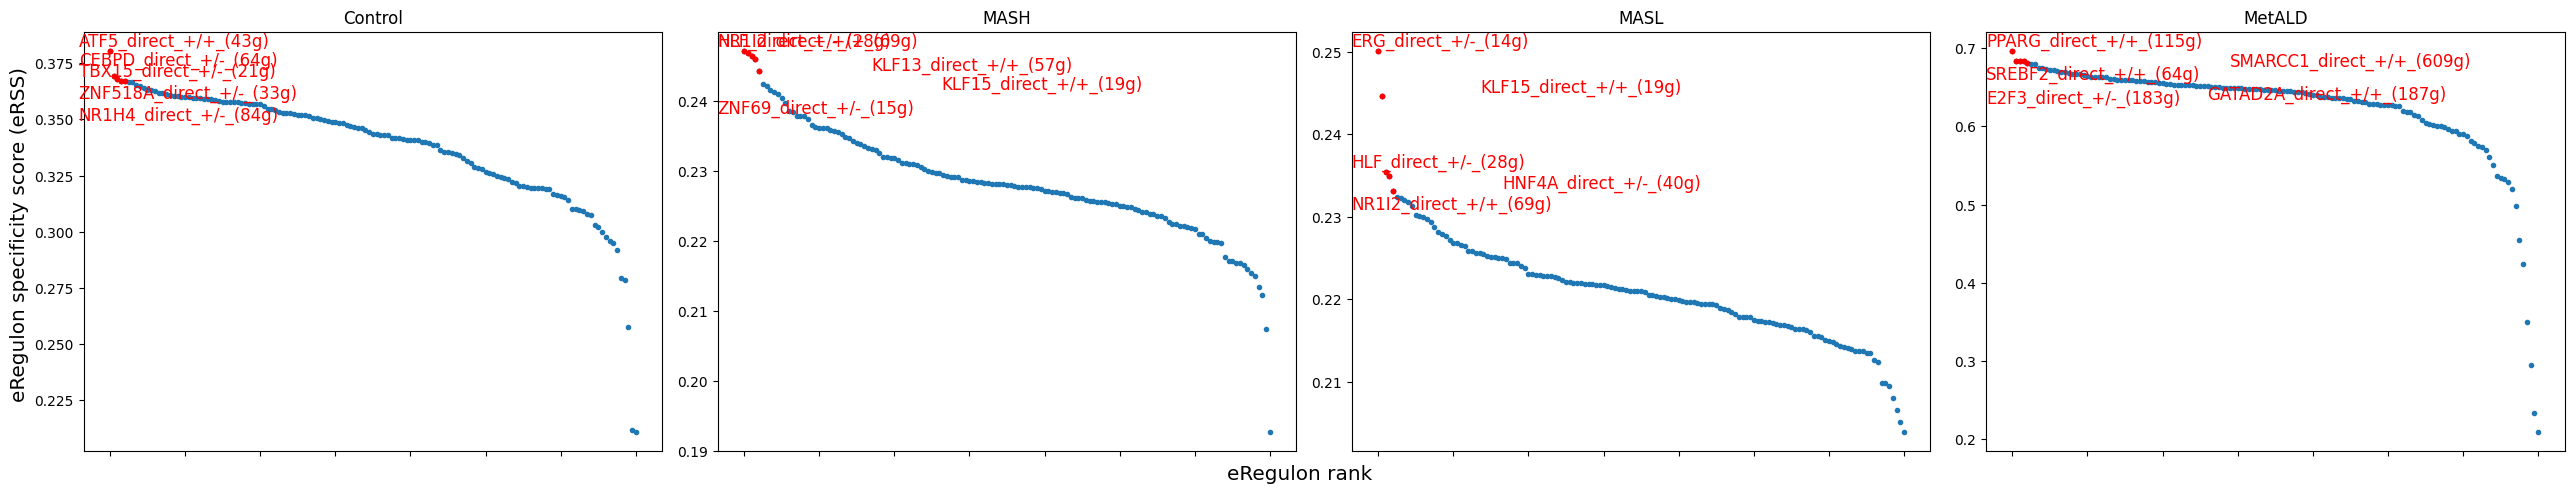

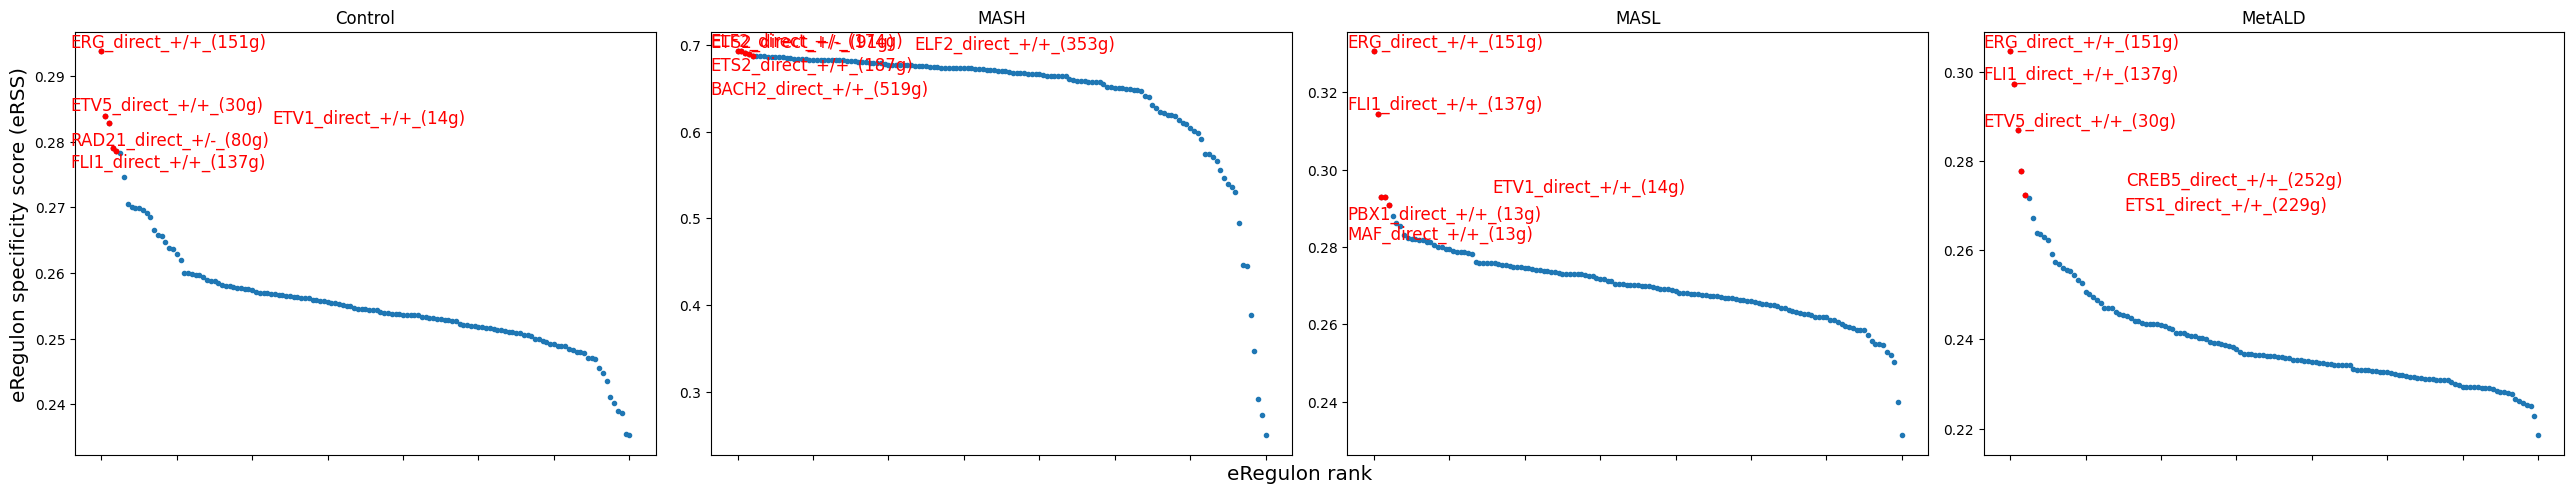

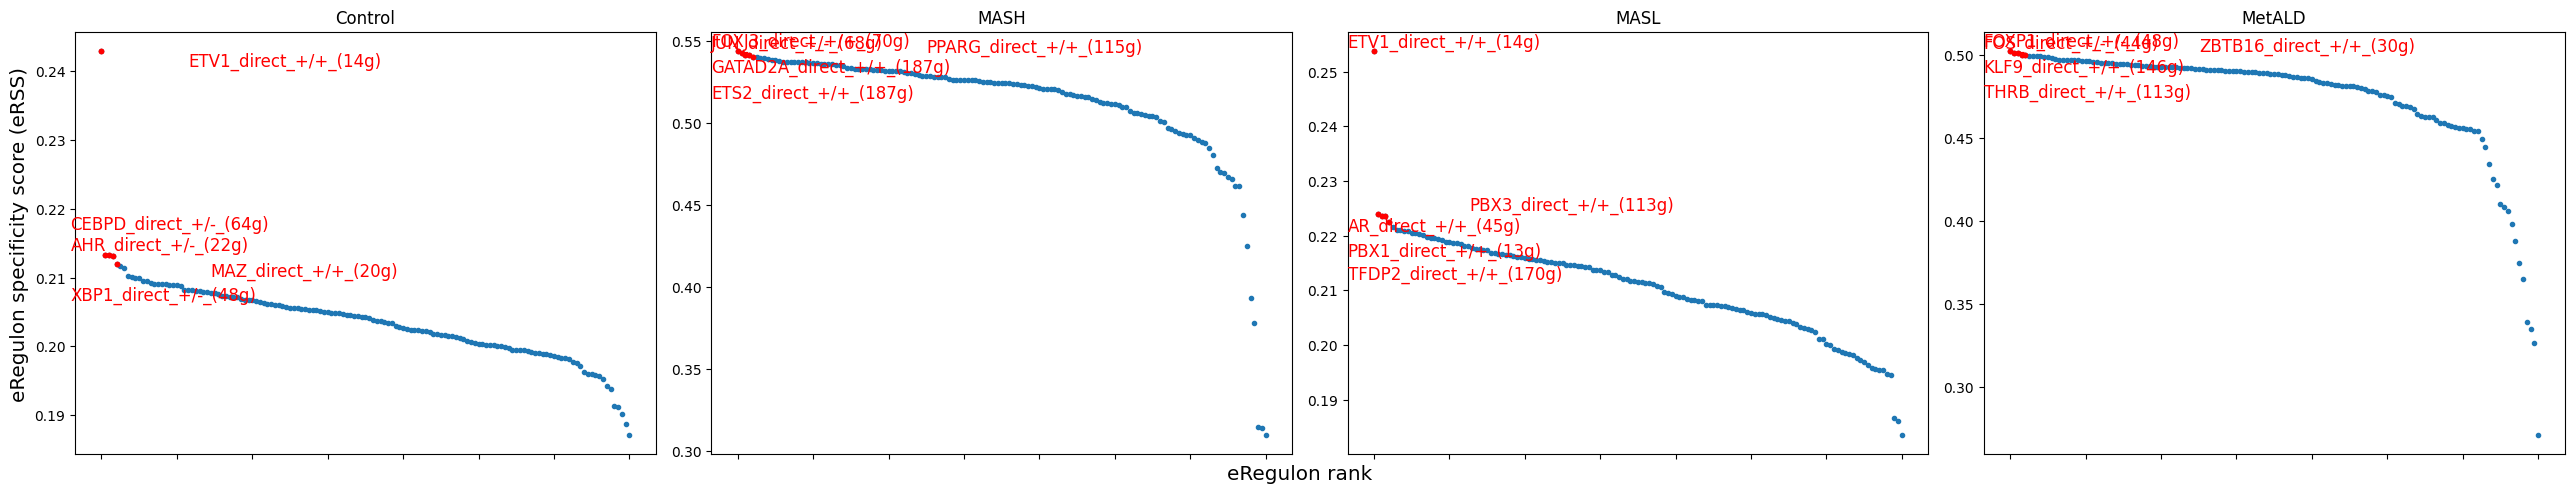

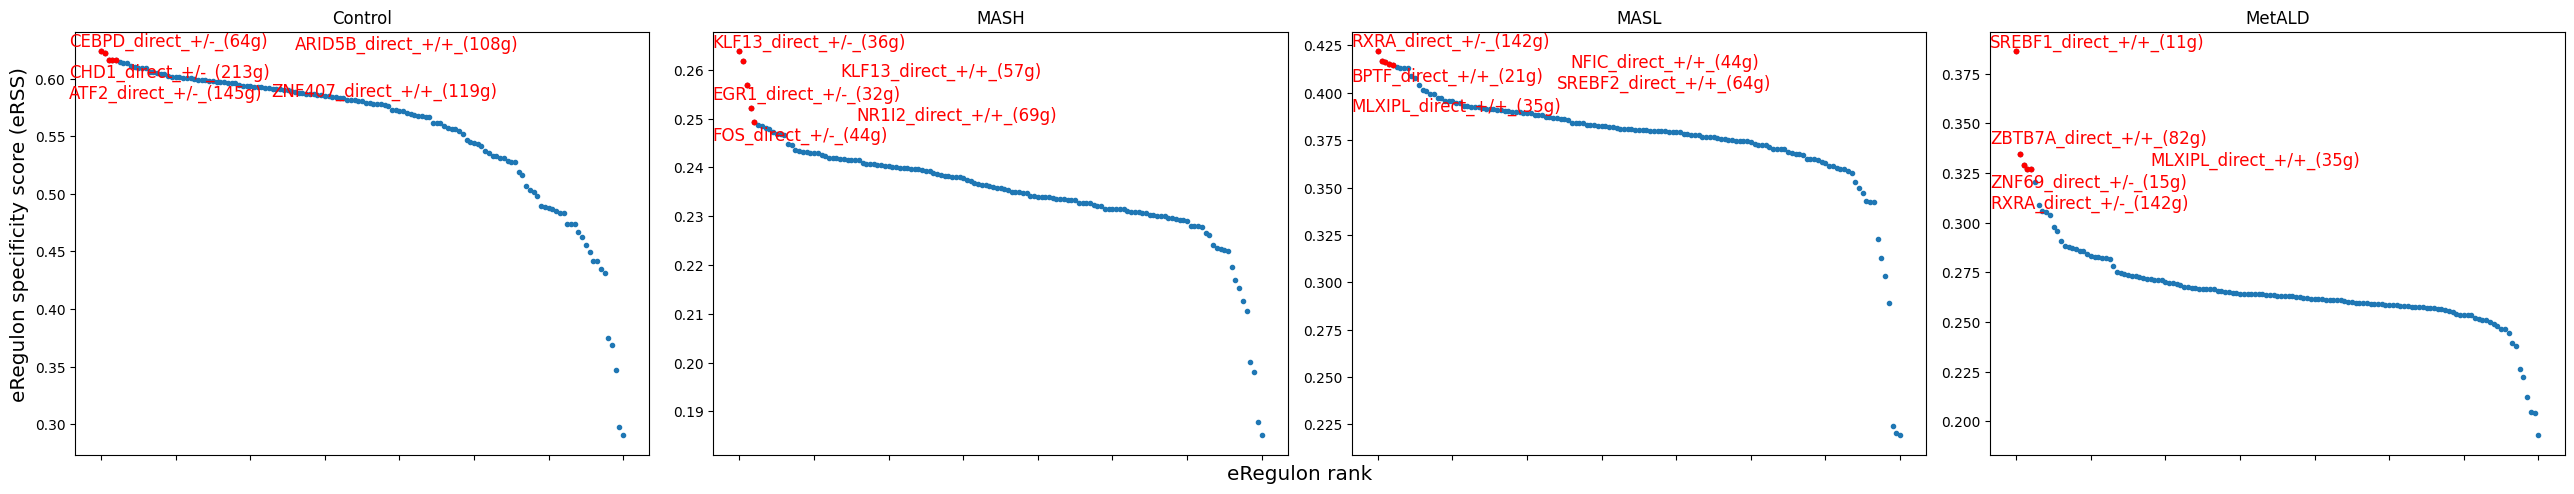

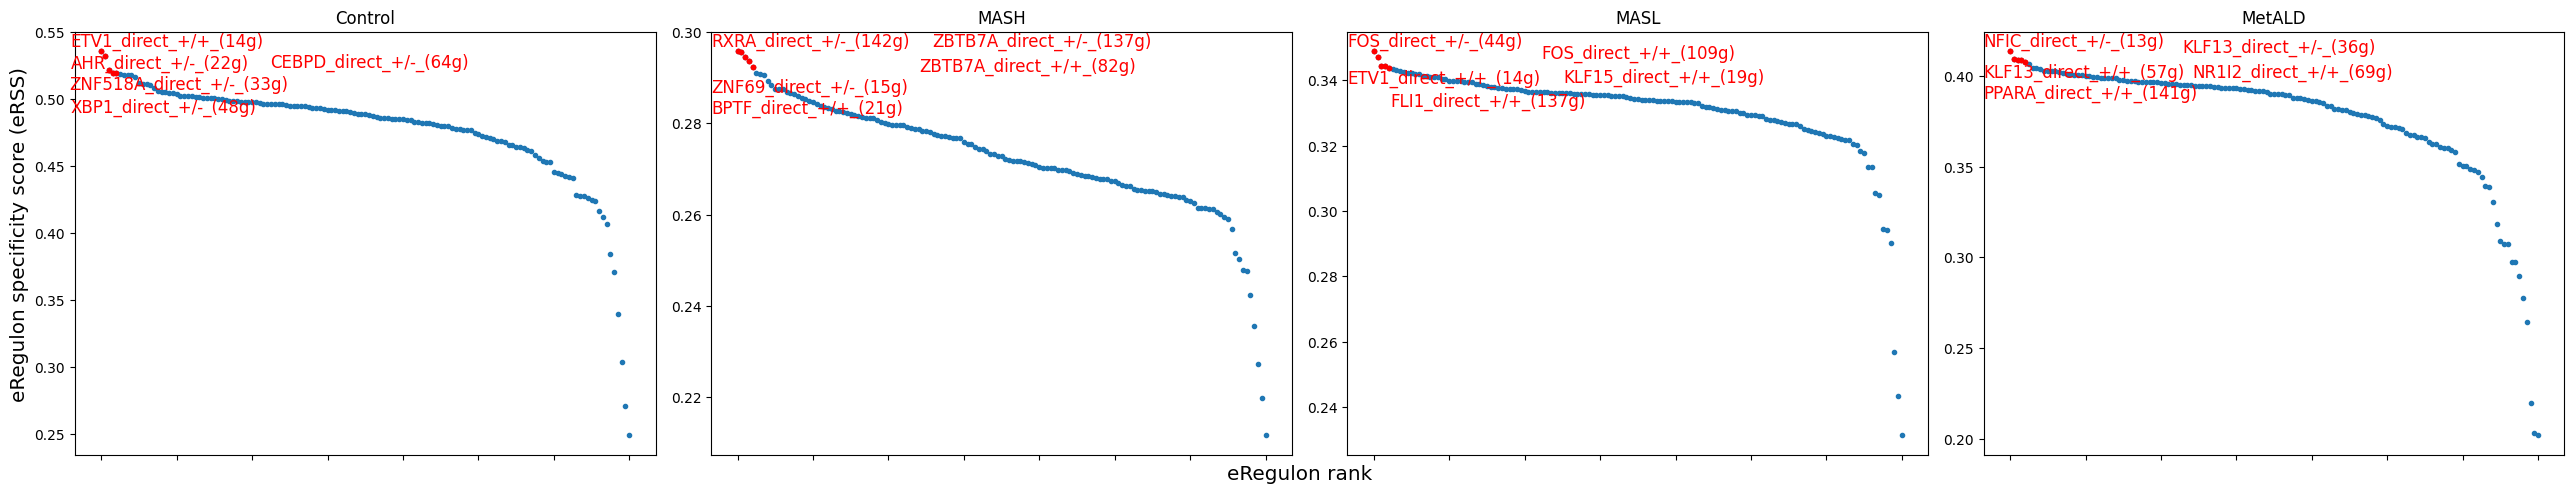

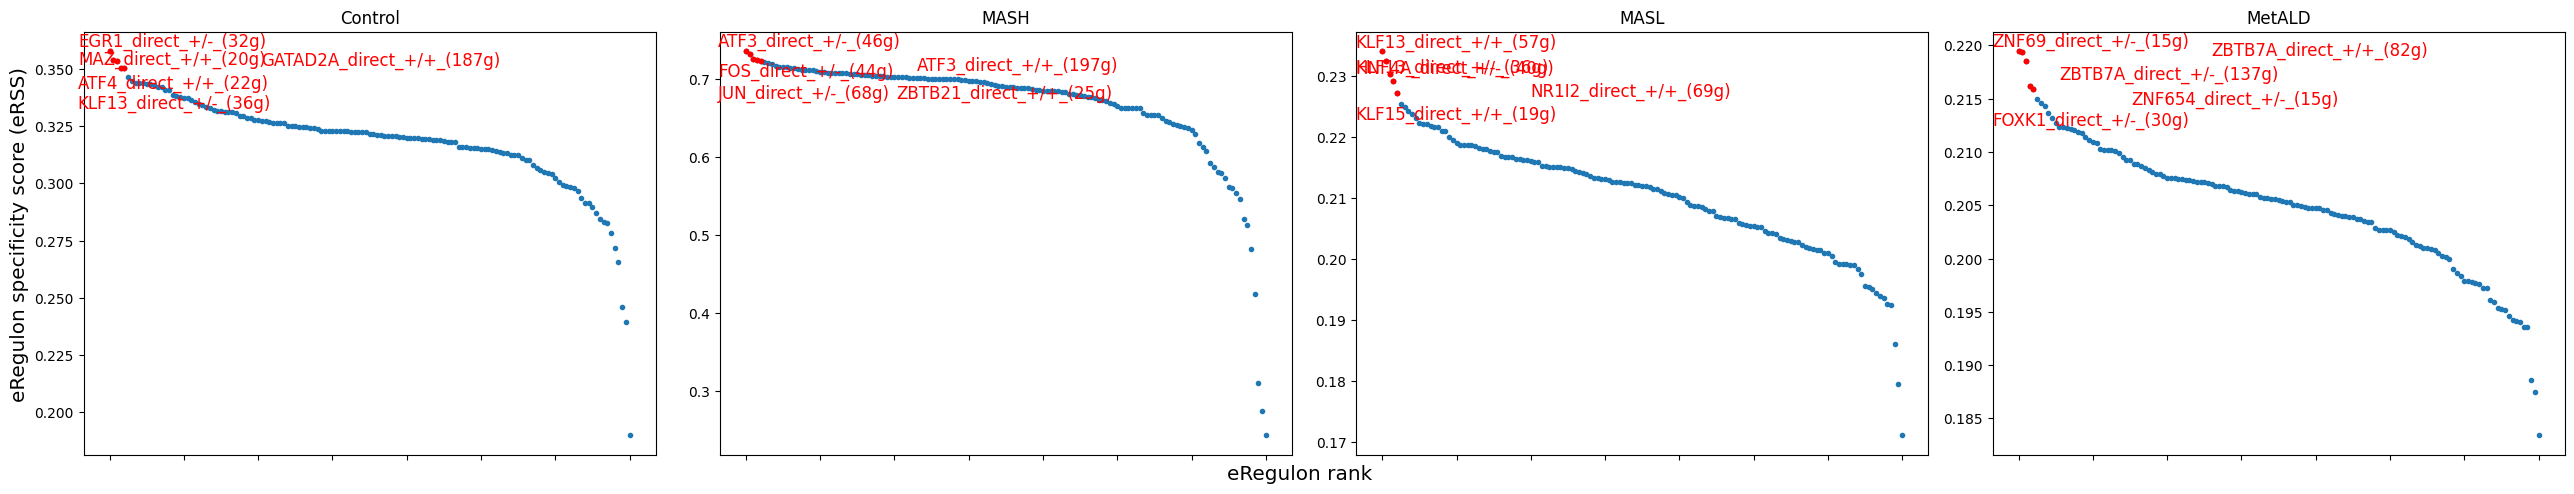

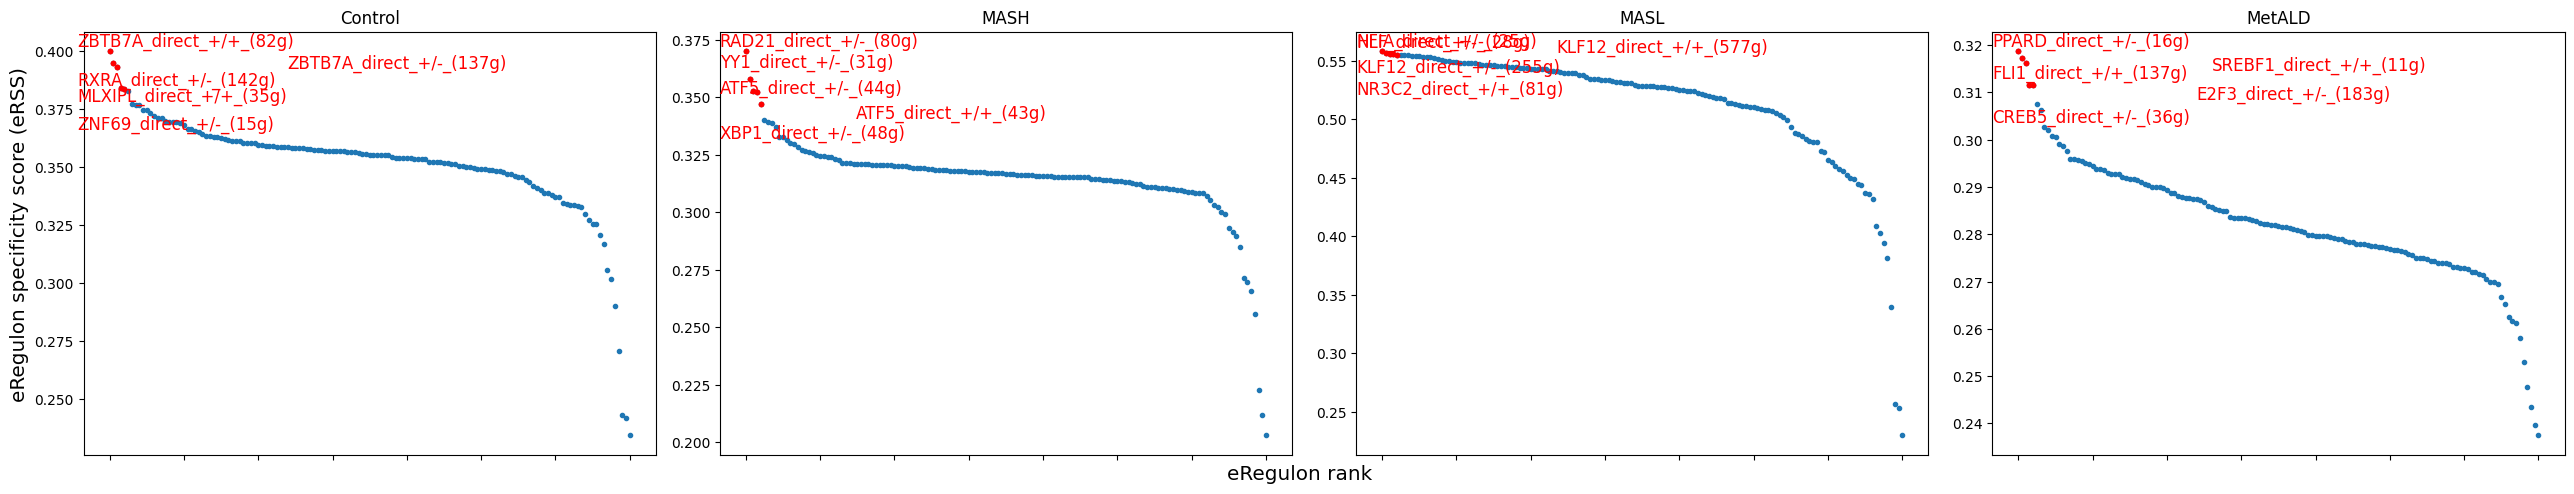

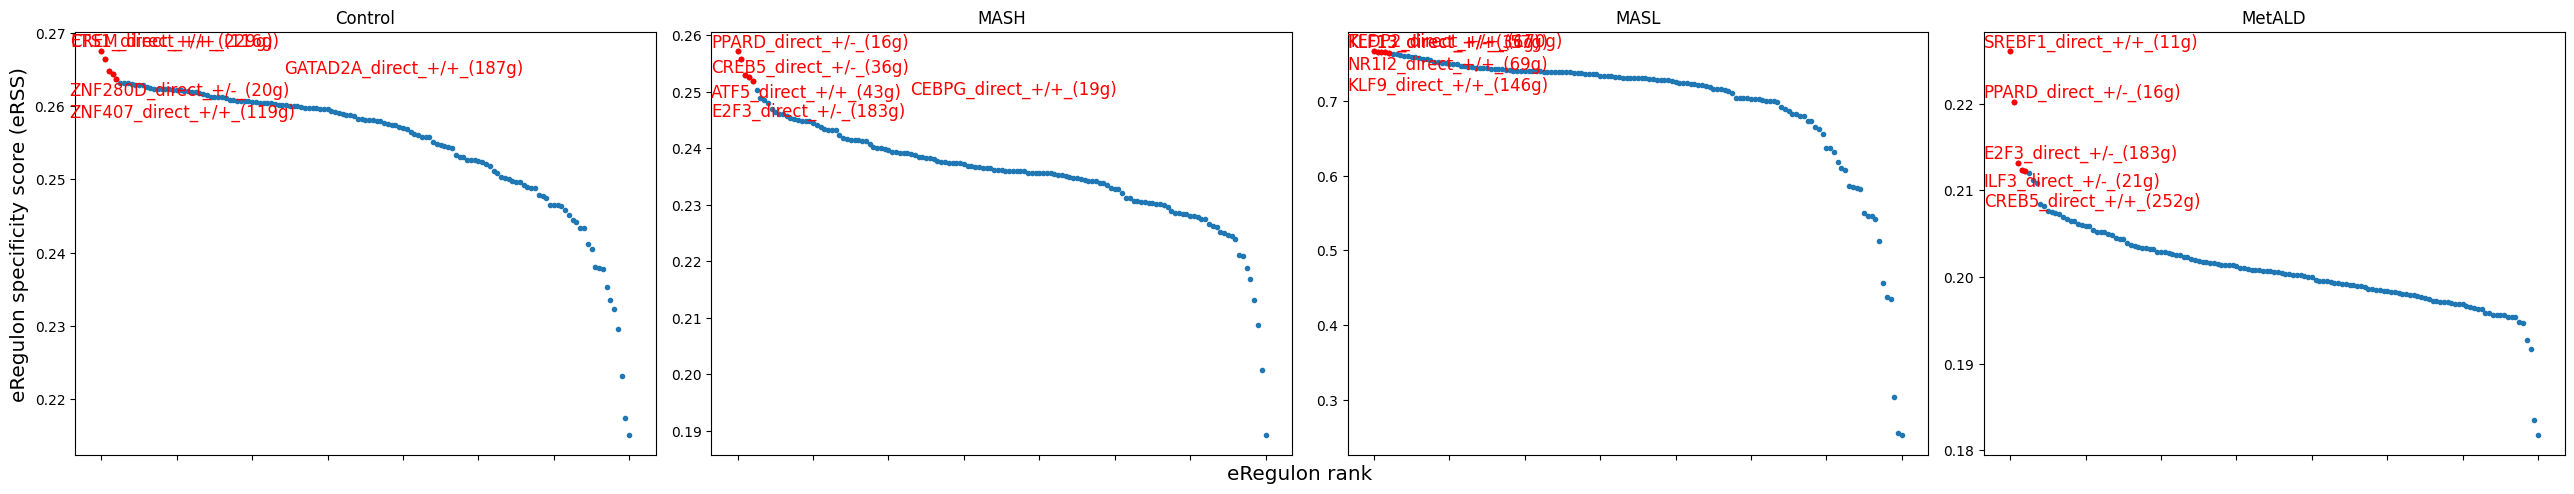

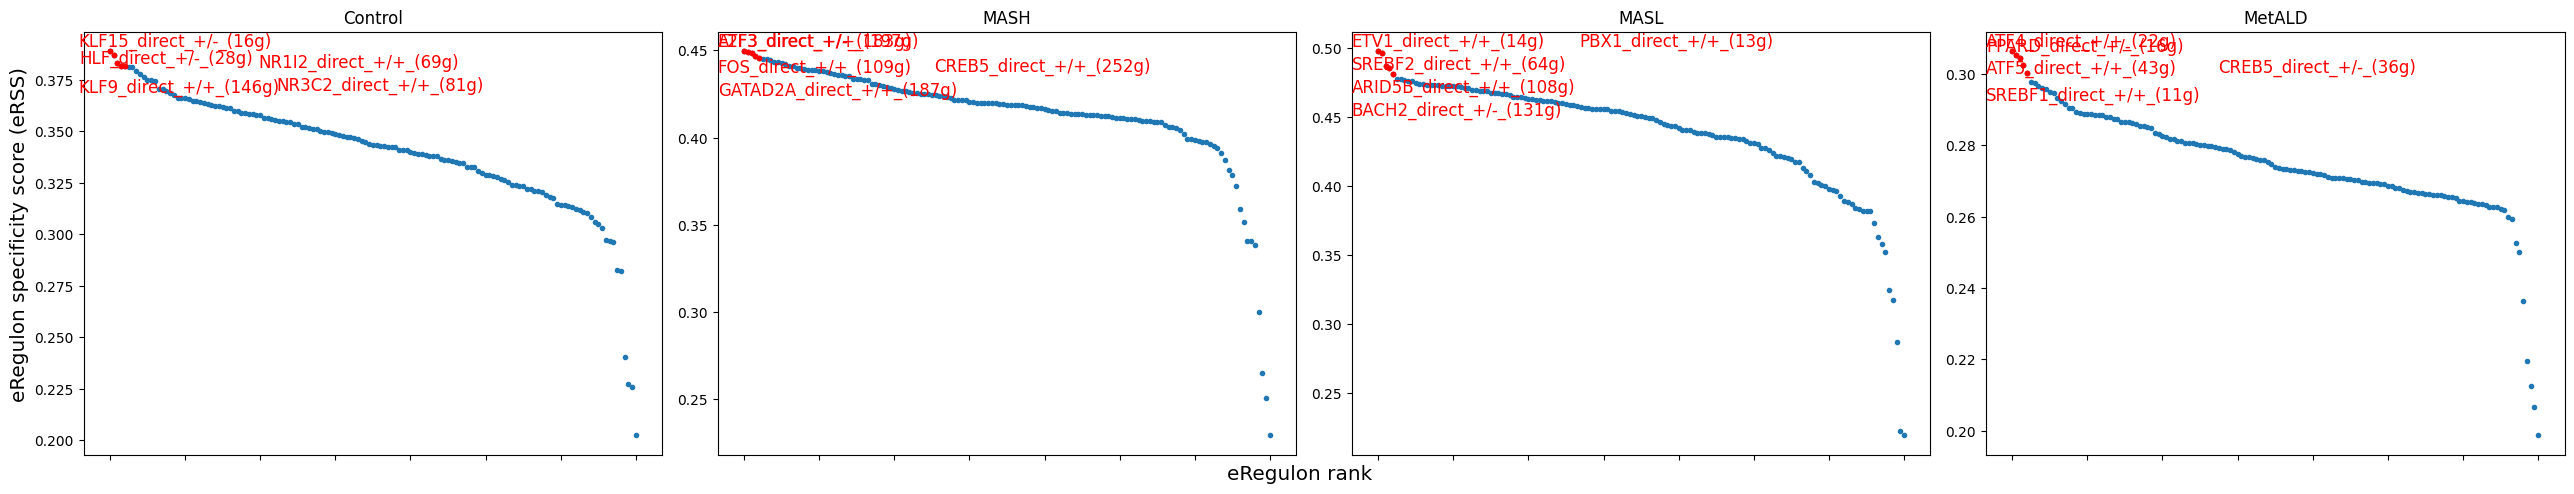

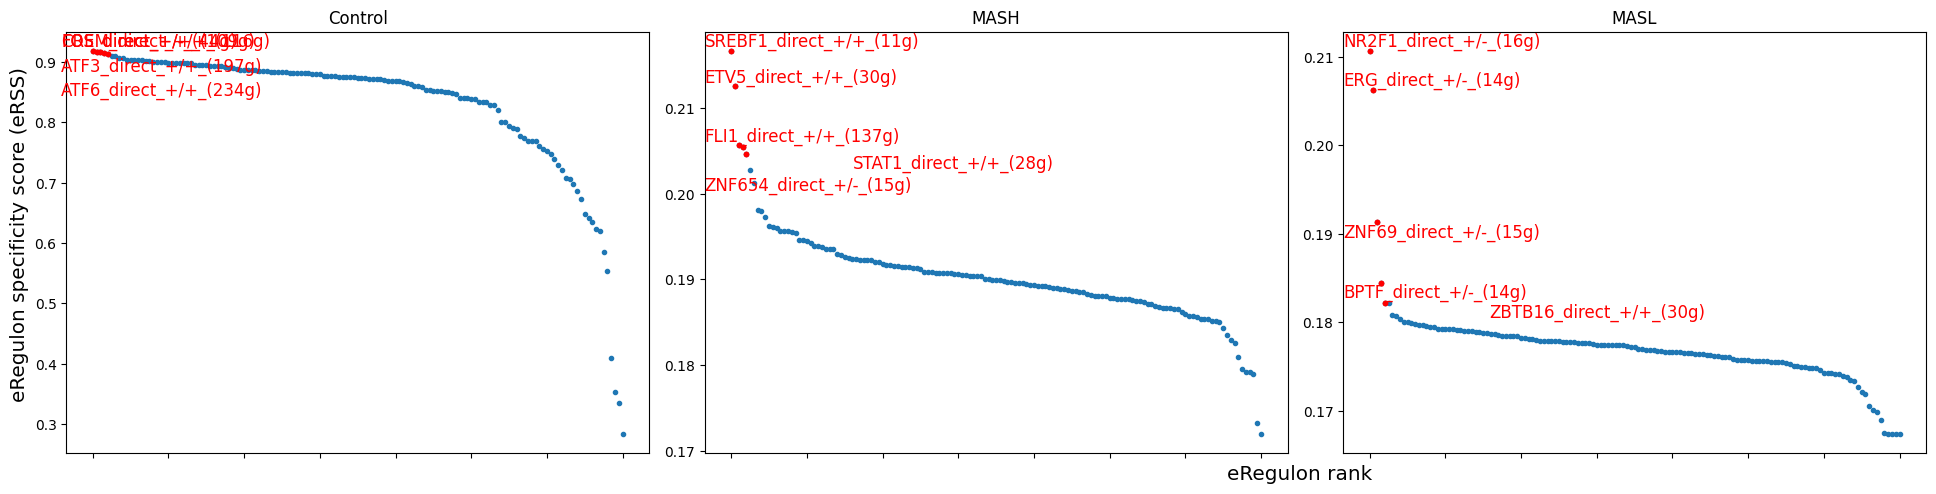

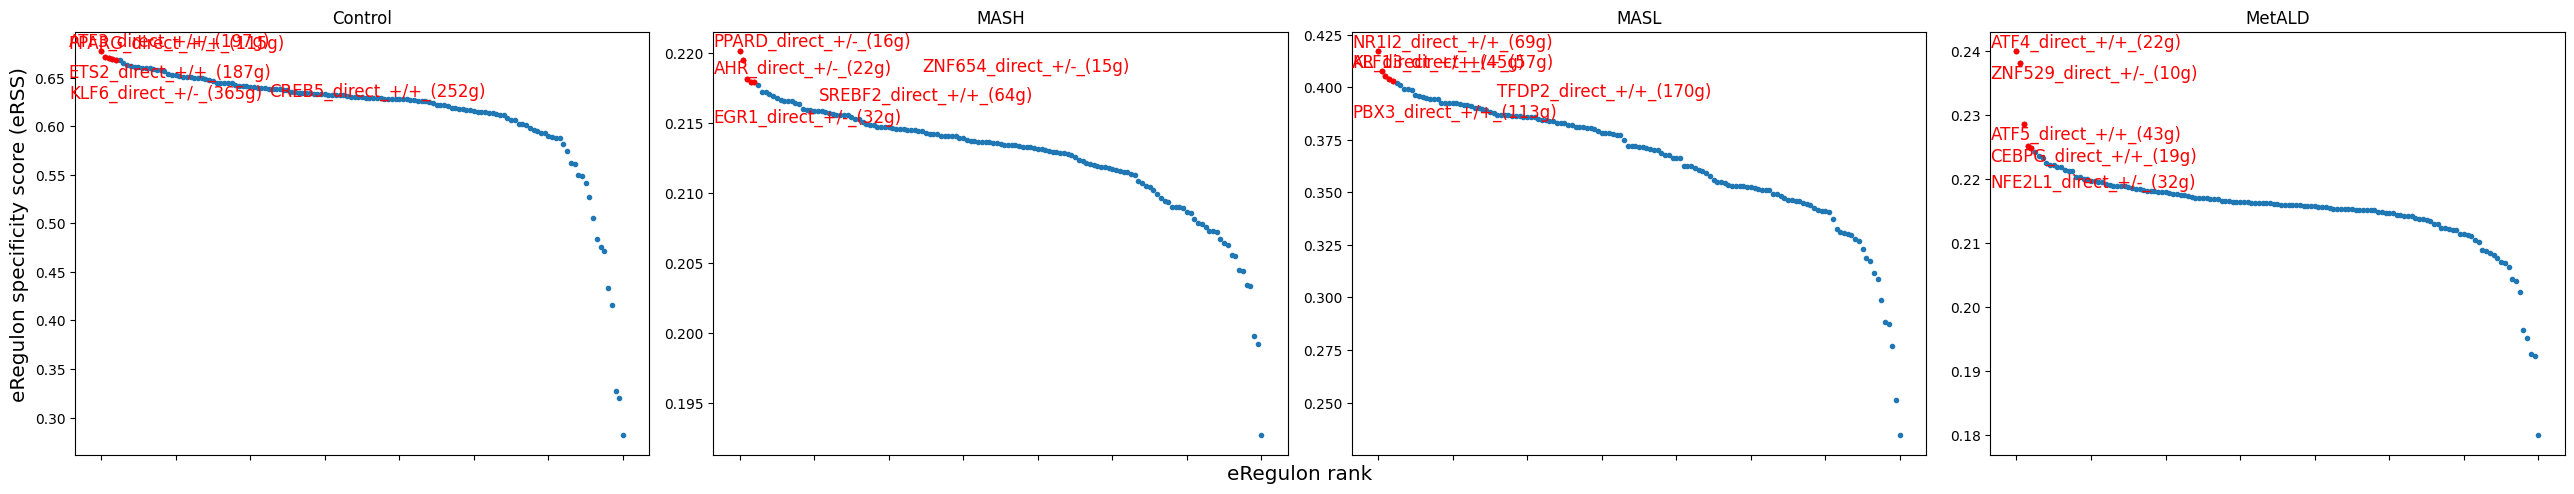

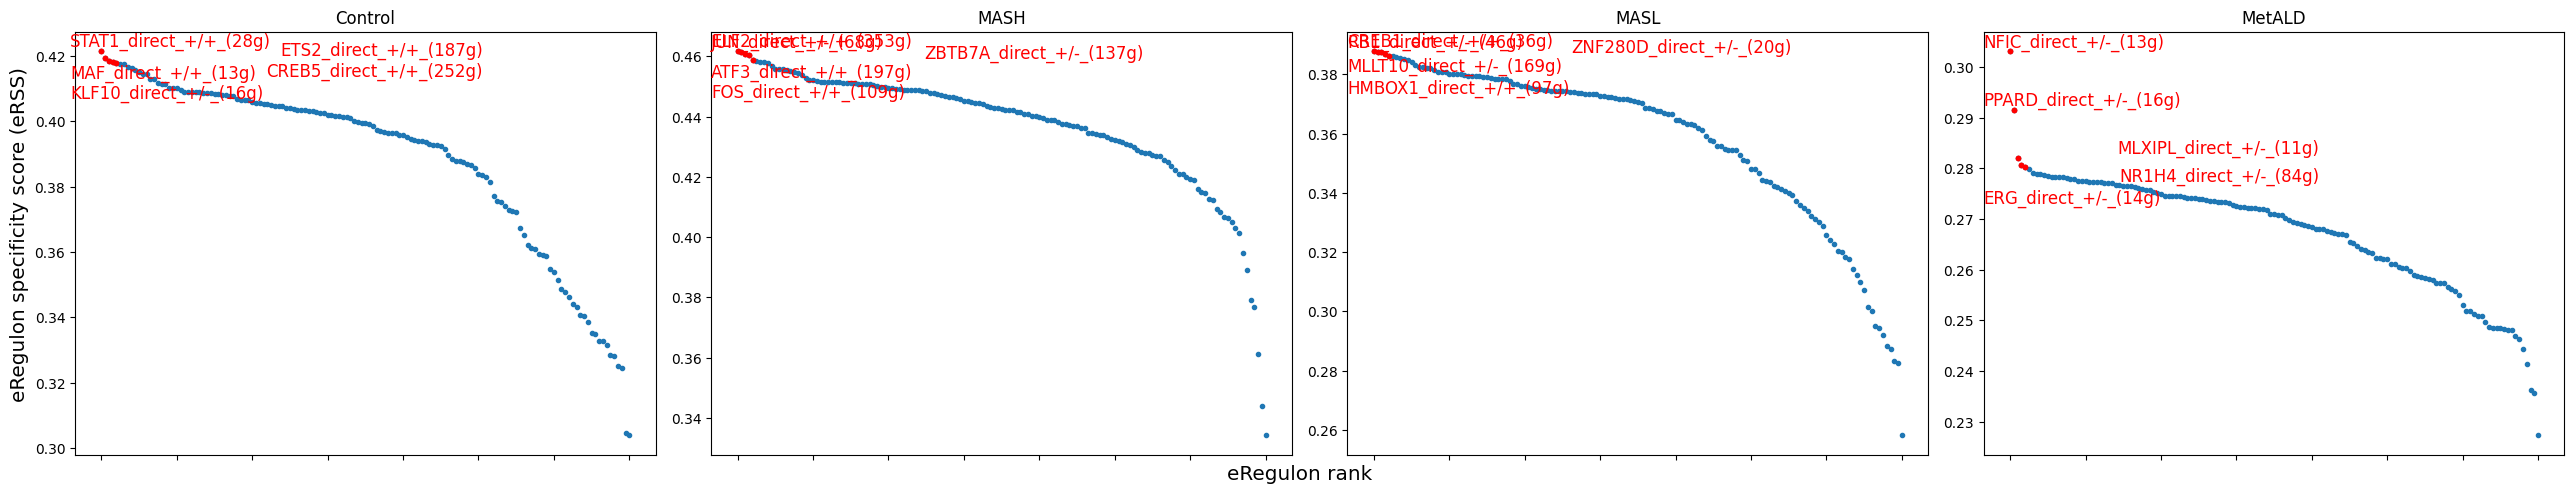

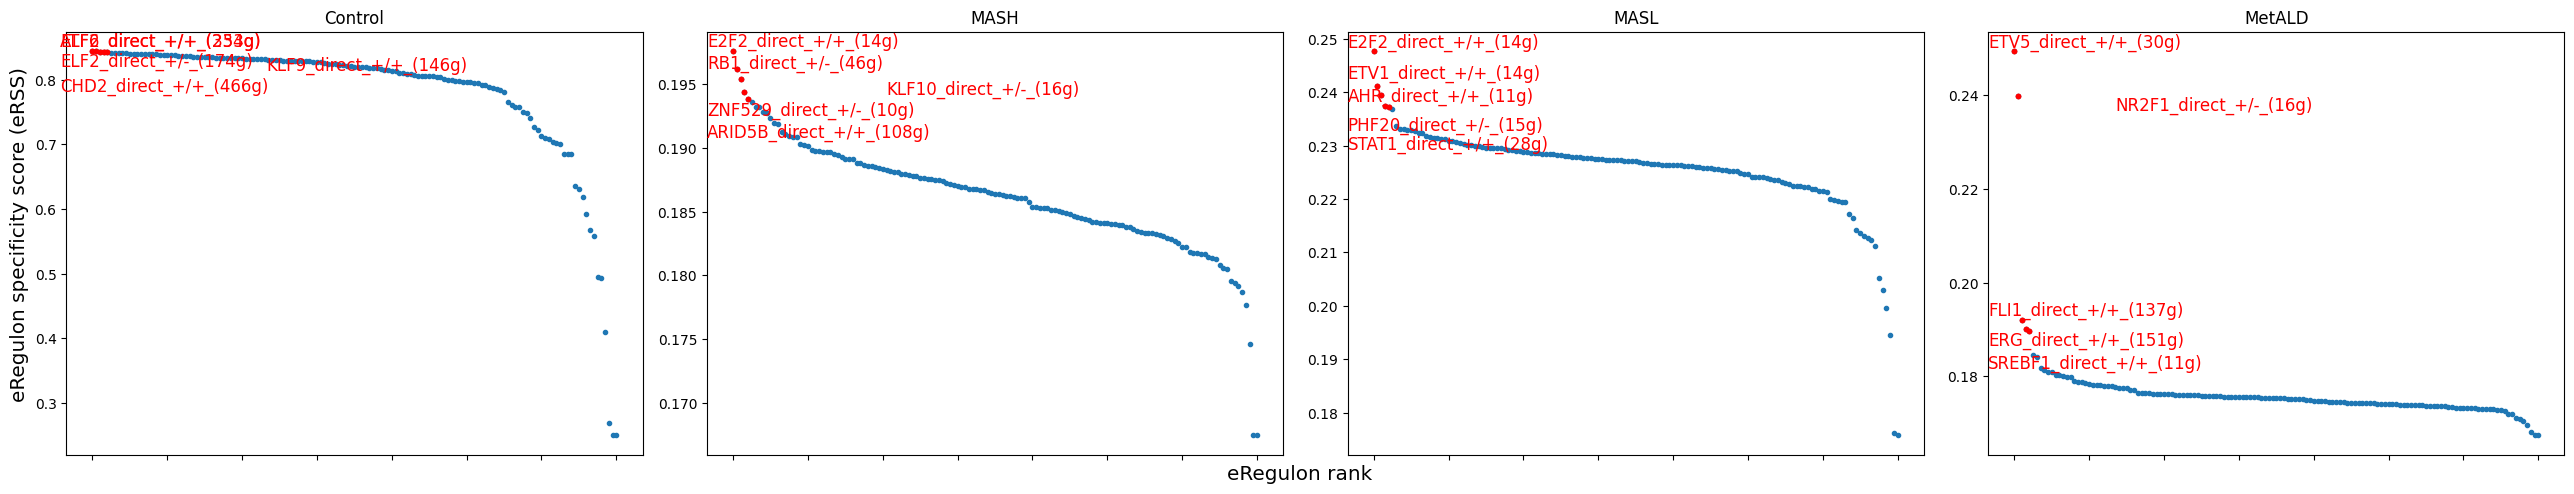

In [7]:
#specificity_report(scplus_mdata, celltype_col, condition_col, outdir)

## Heatmaps

### Removed outlier clusters and filter for TF 

In [6]:
dff = make_heatmap_df(scplus_mdata, celltype_col, motifAnno = 'direct', onlypos = True)

KeyError: 'scRNA_counts:leiden'

In [ ]:
dff

In [ ]:
TFS = 'ETS1 RUNX1 TEAD1 JUN RELB'.split(' ')
TFS

In [ ]:
eregs = [f'{tf}_direct_+/+' for tf in TFS]
eregs

In [ ]:
dff = dff[dff['eRegulon_name'].isin(eregs)]

In [ ]:
dff

In [ ]:
order = 'Control MASL MASH MetALD'.split()
order

In [25]:
heatmap_plotting(scplus_mdata, dff, condition_col, outdir, motifAnno = "direct", name = 'hep_ko_grns', height = 6, width=6, onlypos=False, order=order)

/tscc/projects/ps-epigen/bpToolbox/Scenic/scripts/heatmap_utils.py:365: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tscc/projects/ps-epigen/bpToolbox/Scenic/scripts/heatmap_utils.py:368: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tscc/projects/ps-epigen/bpToolbox/Scenic/scripts/heatmap_utils.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

### Remake with new condition column

In [9]:
meta = pd.read_csv('/tscc/projects/ps-epigen/users/cmiciano/Liver/NASH_NAFLD_pooling/outputs/sandbox/pt2_v5/Seurat_Objects/lfnih_multi_atac_heps_lognorm_clust_md.txt', sep =" ")

In [10]:
# join to subset our 50k 
meta_j = scplus_mdata.obs.join(meta)

In [11]:
## nice 
len(meta_j)

50000

In [12]:
meta_j.columns

Index(['scRNA_counts:orig.ident', 'scRNA_counts:nCount_RNA',
       'scRNA_counts:nFeature_RNA', 'scRNA_counts:donor',
       'scRNA_counts:donor_assay', 'scRNA_counts:percent.mt',
       'scRNA_counts:celltype', 'scRNA_counts:subcelltype',
       'scRNA_counts:batch', 'scRNA_counts:assay',
       'scRNA_counts:donors_combined', 'scRNA_counts:alcohol',
       'scRNA_counts:Steatosis.grade', 'scRNA_counts:Fibrosis.stage',
       'scRNA_counts:condition', 'scRNA_counts:X_scvi_batch',
       'scRNA_counts:X_scvi_labels', 'scRNA_counts:leiden',
       'scRNA_counts:batch_new', 'scRNA_counts:leverage.score',
       'scATAC_counts:cisTopic_nr_frag', 'scATAC_counts:cisTopic_log_nr_frag',
       'scATAC_counts:cisTopic_nr_acc', 'scATAC_counts:cisTopic_log_nr_acc',
       'scATAC_counts:sample_id', 'orig.ident', 'nCount_cpeaks',
       'nFeature_cpeaks', 'sample', 'donor', 'donor_assay', 'nCount_RNA',
       'nFeature_RNA', 'percent.mt', 'celltype', 'subcelltype', 'batch',
       'assay', 'dono

In [13]:
## Write metadata to RNA specific obs 
scplus_mdata['scRNA_counts'].obs['cond_fib_comb'] = meta['condition_fibrosis_group_combined']

In [29]:
dff = make_heatmap_df(scplus_mdata, 'cond_fib_comb', motifAnno = 'direct', onlypos = True)

In [30]:
dff

,scRNA_counts:cond_fib_comb,direct_gene_based_AUC,eRegulon_name,direct_region_based_AUC,specificity,specificity_scaled,TF_avg_scaled,TF_avg
0,Control,0.593347,AHR_direct_+/+,1.000000,0.404402,0.915968,1.000000,1.836075
1,Control,0.563646,AR_direct_+/+,0.631510,0.420862,0.844268,0.745597,4.091626
2,Control,1.000000,ARID5B_direct_+/+,1.000000,0.436928,1.000000,1.000000,1.295453
3,Control,0.256720,ATF3_direct_+/+,0.088056,0.408033,1.000000,0.302196,0.255363
4,Control,0.453996,ATF4_direct_+/+,0.540829,0.386603,1.000000,0.163227,0.194947
...,...,...,...,...,...,...,...,...
299,MASL,0.000000,ZBTB7A_direct_+/+,0.174504,0.369236,0.842228,0.000000,0.224156
300,MASL,1.000000,ZNF148_direct_+/+,0.805077,0.423484,0.952084,0.730424,2.164546
301,MASL,1.000000,ZNF280D_direct_+/+,0.849392,0.428382,0.962547,0.701172,2.048831
302,MASL,0.697783,ZNF407_direct_+/+,0.839375,0.419738,0.910606,0.150427,2.434351


In [33]:
order = ['Control', 'MASL', 'MASH_all_LF', 'MASH_all_HF']

In [34]:
heatmap_plotting(scplus_mdata, dff, 'cond_fib_comb', outdir, motifAnno = "direct", name = 'hep_fib_com', height = 17, width=6, onlypos=True, order=order)

/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 17 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_fib_com_direct_onlypos_celltype_TFe_spec_heatmap.pdf
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 17 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_fib_com_direct_onlypos_celltype_AUC_scaled_heatmap.pdf


In [15]:
#dff = make_heatmap_df(scplus_mdata, 'cond_fib_comb', motifAnno = 'extended', onlypos = False)

In [ ]:
### Other condition fib group

In [40]:
meta['condition_fibrosis_group'].unique()

array(['MASL', 'MetALD_LF', 'Control', 'MASH_LF', 'MetALD_HF', 'MASH_HF'],
      dtype=object)

In [41]:
#meta['condition_fibrosis_group']

In [16]:
scplus_mdata['scRNA_counts'].obs['cond_fib_met'] = meta['condition_fibrosis_group']
scplus_mdata.obs['scRNA_counts:cond_fib_met'] = meta['condition_fibrosis_group']
## add to all sc_meta?? 

In [17]:
#meta['condition_fibrosis_group'].unique()

In [18]:
scplus_mdata['scRNA_counts'].obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor', 'donor_assay',
       'percent.mt', 'celltype', 'subcelltype', 'batch', 'assay',
       'donors_combined', 'alcohol', 'Steatosis.grade', 'Fibrosis.stage',
       'condition', 'X_scvi_batch', 'X_scvi_labels', 'leiden', 'batch_new',
       'leverage.score', 'cond_fib_comb', 'cond_fib_met'],
      dtype='object')

In [19]:
scplus_mdata.obs.columns

Index(['scRNA_counts:orig.ident', 'scRNA_counts:nCount_RNA',
       'scRNA_counts:nFeature_RNA', 'scRNA_counts:donor',
       'scRNA_counts:donor_assay', 'scRNA_counts:percent.mt',
       'scRNA_counts:celltype', 'scRNA_counts:subcelltype',
       'scRNA_counts:batch', 'scRNA_counts:assay',
       'scRNA_counts:donors_combined', 'scRNA_counts:alcohol',
       'scRNA_counts:Steatosis.grade', 'scRNA_counts:Fibrosis.stage',
       'scRNA_counts:condition', 'scRNA_counts:X_scvi_batch',
       'scRNA_counts:X_scvi_labels', 'scRNA_counts:leiden',
       'scRNA_counts:batch_new', 'scRNA_counts:leverage.score',
       'scATAC_counts:cisTopic_nr_frag', 'scATAC_counts:cisTopic_log_nr_frag',
       'scATAC_counts:cisTopic_nr_acc', 'scATAC_counts:cisTopic_log_nr_acc',
       'scATAC_counts:sample_id', 'scRNA_counts:cond_fib_met'],
      dtype='object')

In [20]:
#scplus_mdata.obs['scRNA_counts:cond_fib_met']

In [57]:
dff = make_heatmap_df(scplus_mdata, 'cond_fib_met', motifAnno = 'direct', onlypos = True)

In [58]:
dff

,scRNA_counts:cond_fib_met,direct_gene_based_AUC,eRegulon_name,direct_region_based_AUC,specificity,specificity_scaled,TF_avg_scaled,TF_avg
0,Control,0.606298,AHR_direct_+/+,1.000000,0.404402,0.940615,1.000000,1.836075
1,Control,0.579677,AR_direct_+/+,0.653499,0.420862,0.880250,0.750804,4.091626
2,Control,1.000000,ARID5B_direct_+/+,0.799895,0.436928,1.000000,1.000000,1.295453
3,Control,0.230552,ATF3_direct_+/+,0.081121,0.408033,1.000000,0.238424,0.255363
4,Control,0.317664,ATF4_direct_+/+,0.360028,0.386603,1.000000,0.150574,0.194947
...,...,...,...,...,...,...,...,...
451,MetALD_LF,0.575467,ZBTB7A_direct_+/+,1.000000,0.261085,0.140877,1.000000,0.511905
452,MetALD_LF,0.581286,ZNF148_direct_+/+,0.125813,0.260248,0.135953,1.000000,2.346190
453,MetALD_LF,0.111564,ZNF280D_direct_+/+,0.433945,0.252858,0.115882,0.676971,1.995238
454,MetALD_LF,0.609620,ZNF407_direct_+/+,0.228670,0.260449,0.135216,0.613435,2.616429


In [59]:
meta['condition_fibrosis_group'].unique()

array(['MASL', 'MetALD_LF', 'Control', 'MASH_LF', 'MetALD_HF', 'MASH_HF'],
      dtype=object)

In [60]:
order = ['Control', 'MASL', 'MASH_LF', 'MASH_HF', 'MetALD_LF', 'MetALD_HF']

In [62]:
heatmap_plotting(scplus_mdata, dff, 'cond_fib_met', outdir, motifAnno = "direct", name = 'hep_fib_metald', height = 17, width=6, onlypos=True, order=order)

/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 17 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_fib_metald_direct_onlypos_celltype_TFe_spec_heatmap.pdf
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 17 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_fib_metald_direct_onlypos_celltype_AUC_scaled_heatmap.pdf


In [25]:
dff = make_heatmap_df(scplus_mdata, 'cond_fib_met', motifAnno = 'extended', onlypos = True)

In [26]:
order = ['Control', 'MASL', 'MASH_LF', 'MASH_HF', 'MetALD_LF', 'MetALD_HF']

In [27]:
heatmap_plotting(scplus_mdata, dff, 'cond_fib_met', outdir, motifAnno = "extended", name = 'hep_fib_metald', height = 17, width=6, onlypos=True, order=order)

/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 17 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_fib_metald_extended_onlypos_TFe_spec_heatmap.pdf
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 17 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_fib_metald_extended_onlypos_AUC_scaled_heatmap.pdf


### Leiden

In [6]:
dff = make_heatmap_df(scplus_mdata, 'leiden', motifAnno = 'direct', onlypos = True)

In [7]:
dff

,scRNA_counts:leiden,direct_gene_based_AUC,eRegulon_name,direct_region_based_AUC,specificity,specificity_scaled,TF_avg_scaled,TF_avg
0,0,0.779737,AHR_direct_+/+,0.737774,0.262769,0.876551,0.758730,2.501362
1,0,0.932105,AR_direct_+/+,0.605936,0.276073,0.962678,0.947077,5.904184
2,0,0.238840,ARID5B_direct_+/+,0.519058,0.248477,0.644512,0.281972,0.860114
3,0,0.062062,ATF3_direct_+/+,0.103364,0.246483,0.588703,0.023477,0.117851
4,0,0.035423,ATF4_direct_+/+,0.042719,0.223102,0.494869,0.281959,0.170834
...,...,...,...,...,...,...,...,...
1667,21,0.038207,ZBTB7A_direct_+/+,0.174075,0.176306,0.000000,0.000000,0.019718
1668,21,0.000000,ZNF148_direct_+/+,0.451509,0.176808,0.009344,0.000000,0.949296
1669,21,0.343109,ZNF280D_direct_+/+,0.749301,0.177534,0.035853,0.038882,0.814085
1670,21,0.000000,ZNF407_direct_+/+,0.533985,0.177065,0.003885,0.430781,2.050704


In [8]:
dff['scRNA_counts:leiden'] = dff['scRNA_counts:leiden'].astype('str')

In [11]:
heatmap_plotting(scplus_mdata, dff, 'leiden', outdir, motifAnno = "direct", name = 'hep_leiden', height = 20, width=14, onlypos=True)

/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 14 x 20 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_leiden_direct_onlypos_TFe_spec_heatmap.pdf
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 14 x 20 in image.
/tscc/nfs/home/rlancione/miniconda3/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: Reports_otsu/Heatmaps/hep_leiden_direct_onlypos_AUC_scaled_heatmap.pdf


In [12]:
### Leiden with 

['AHR', 'AR', 'ARID5B', 'ATF3', 'ATF4']